# Image Phrase Compilation

Per-image compilation of **original phrases**, their **sentiments**, and extracted **word stems**.

### Pipeline
1. Load `image_phrase_word_mapping.csv` (one row per image) as the base table
2. Add **originalPhrases** from `image_phrase_matching.csv` (Original column, semicolon-separated)
3. Add **originalSentiments** from `term_mapping.csv` (OriginalSign, matching phrase order)
4. Drop `words_from_humanCurated` and `words_from_finalPhrases`
5. Extract **originalStems** and **originalStemPOS** from original phrases (validated against `unique_stems.csv`)
6. Save to `phrase_reduction_v2/image_compiled_phrases.csv`

### Final column order
`imageName, imageURL, VisType, NormalizedVC, Topics, SubTopics, originalPhrases, originalSentiments, originalStems, originalStemPOS, objectWords, actionWords, humanCuratedPhrases, finalPhrases`

In [96]:
import pandas as pd
import re
import spacy
from nltk.stem import SnowballStemmer
from collections import defaultdict

nlp = spacy.load('en_core_web_sm')
stemmer = SnowballStemmer('english')

# ── Load all source tables ──────────────────────────────────────────────────────
df_base = pd.read_csv('phrase_reduction_v2/image_phrase_word_mapping.csv')
df_match = pd.read_csv('figures/image_phrase_matching.csv')
df_term = pd.read_csv('figures/term_mapping.csv')
df_stems = pd.read_csv('figures/unique_stems.csv')
df_shortlist = pd.read_csv('phrase_reduction_v2/phrase_shortlist.csv')

print(f'Base table:            {len(df_base)} images, columns: {df_base.columns.tolist()}')
print(f'Phrase matching:       {len(df_match)} records, {df_match["ImageName"].nunique()} unique images')
print(f'Term mapping:          {len(df_term)} entries')

print(f'Unique stems (Original): {df_stems["OriginalWord"].dropna().nunique()} unique words')
print(f'Phrase shortlist:      {len(df_shortlist)} final phrases across {df_shortlist["primary_topic"].nunique()} topics')

Base table:            520 images, columns: ['imageName', 'imageURL', 'VisType', 'Topics', 'humanCuratedPhrases', 'finalPhrases', 'words_from_humanCurated', 'words_from_finalPhrases']
Phrase matching:       1909 records, 493 unique images
Term mapping:          1582 entries
Unique stems (Original): 678 unique words
Phrase shortlist:      20 final phrases across 7 topics


## Add Original Phrases & Sentiments

- Group `image_phrase_matching` by ImageName → semicolon-separated unique Original phrases
- Look up each phrase's sentiment (`OriginalSign`) from `term_mapping`
- Drop `words_from_humanCurated` and `words_from_finalPhrases`
- Save intermediate result

In [124]:
import json

# ── Build per-image original phrases (deduplicated, preserving order) ────────────
img_originals = {}
for img_name, grp in df_match.groupby('ImageName'):
    seen = set()
    phrases = []
    for phrase in grp['Original'].dropna():
        p = phrase.strip()
        if p and p not in seen:
            seen.add(p)
            phrases.append(p)
    img_originals[img_name] = '; '.join(phrases)

# ── Fallback: for images missing from df_match, extract phrases from sheet 1103808983 ──
# The ExtractedPhrases columns contain JSON: {"Topic": ["(+) phrase", ...], ...}
# We parse the JSON, strip the (+)/(-) prefix to get clean phrases, and store sentiments.
missing_imgs = set(df_base['imageName']) - set(img_originals.keys())
fallback_sentiments = {}  # img -> list of sentiment strings matching phrase order

def parse_extracted_json(raw):
    """Parse a JSON-format extracted phrases cell.
    Returns list of (phrase, sentiment) tuples."""
    results = []
    raw = raw.strip()
    if not raw or raw == 'nan' or raw == '{}':
        return results
    if not raw.startswith('{'):
        # Plain text fallback (comma-separated)
        for p in re.split(r',(?![^(]*\))', raw):
            p = p.strip()
            if p:
                results.append((p, '?'))
        return results
    try:
        obj = json.loads(raw)
    except json.JSONDecodeError:
        # Try fixing common issues: semicolons used as separators instead of commas
        fixed = raw.replace(';\n', ',\n').replace('; "', ', "')
        try:
            obj = json.loads(fixed)
        except json.JSONDecodeError:
            # Last resort: treat as plain text
            for p in re.split(r'[;,]', raw):
                p = p.strip().strip('"').strip('{').strip('}').strip()
                if p and not p.startswith('"') and len(p) > 3:
                    results.append((p, '?'))
            return results
    if isinstance(obj, dict):
        for topic, phrases in obj.items():
            if isinstance(phrases, list):
                for entry in phrases:
                    if not isinstance(entry, str):
                        continue
                    entry = entry.strip()
                    # Extract sentiment prefix: "(+) phrase" or "(-) phrase"
                    sent = '?'
                    m = re.match(r'^\(([+-])\)\s*', entry)
                    if m:
                        sent = f'({m.group(1)})'
                        entry = entry[m.end():].strip()
                    if entry:
                        results.append((entry, sent))
    return results

if missing_imgs:
    _spreadsheet_id = '1gfeYdT-RxLq9tvNpfv_P8AIKg2eSz6-8bSv5zUJsWEc'
    _df_pairs = pd.read_csv(
        f'https://docs.google.com/spreadsheets/d/{_spreadsheet_id}/export?gid=1103808983&format=csv'
    )
    # Collect extracted phrases per image from both sides of each comparison
    _img_extracted = defaultdict(list)  # img -> list of (phrase, sentiment)
    for _, row in _df_pairs.iterrows():
        for img_col, phrase_col in [
            ('moreComplexImageName', 'ExtractedPhrasesMoreComplex'),
            ('lessComplexImageName', 'ExtractedPhrasesLessComplex'),
        ]:
            img = str(row.get(img_col, '')).strip()
            raw = str(row.get(phrase_col, '')).strip()
            if img in missing_imgs and raw and raw != 'nan':
                parsed = parse_extracted_json(raw)
                _img_extracted[img].extend(parsed)

    n_filled = 0
    for img in missing_imgs:
        if img in _img_extracted:
            # Deduplicate while preserving order
            seen = set()
            deduped_phrases = []
            deduped_sents = []
            for phrase, sent in _img_extracted[img]:
                if phrase not in seen:
                    seen.add(phrase)
                    deduped_phrases.append(phrase)
                    deduped_sents.append(sent)
            if deduped_phrases:
                img_originals[img] = '; '.join(deduped_phrases)
                fallback_sentiments[img] = deduped_sents
                n_filled += 1
    print(f'Fallback from sheet 1103808983: {n_filled}/{len(missing_imgs)} missing images got original phrases')
    # Show a few examples
    for img in sorted(fallback_sentiments)[:3]:
        print(f'  {img}: phrases={img_originals[img][:80]}...')
        print(f'               sents={fallback_sentiments[img]}')

# ── Build sentiment lookup from term_mapping ────────────────────────────────────
sentiment_lookup = {}
for _, row in df_term.iterrows():
    orig = row['original']
    sign = row['OriginalSign']
    if isinstance(orig, str) and isinstance(sign, str):
        sentiment_lookup[orig.strip()] = sign.strip()

print(f'Sentiment lookup: {len(sentiment_lookup)} original phrases mapped')

# ── Add columns to df_base ──────────────────────────────────────────────────────
df_base['originalPhrases'] = df_base['imageName'].map(img_originals).fillna('')

def get_sentiments(row):
    img = row['imageName']
    phrases_str = row['originalPhrases']
    if not isinstance(phrases_str, str) or phrases_str.strip() == '':
        return ''
    # Use fallback sentiments if available (extracted from JSON)
    if img in fallback_sentiments:
        return '; '.join(fallback_sentiments[img])
    # Otherwise look up in term_mapping
    phrases = [p.strip() for p in phrases_str.split(';') if p.strip()]
    signs = [sentiment_lookup.get(p, '?') for p in phrases]
    return '; '.join(signs)

df_base['originalSentiments'] = df_base.apply(get_sentiments, axis=1)

# ── Drop word columns ──────────────────────────────────────────────────────────
df_base = df_base.drop(columns=['words_from_humanCurated', 'words_from_finalPhrases'], errors='ignore')

# ── Coverage stats ──────────────────────────────────────────────────────────────
n_with = (df_base['originalPhrases'] != '').sum()
n_without = (df_base['originalPhrases'] == '').sum()
print(f'Images with original phrases: {n_with}, without: {n_without}')

# Sentiment coverage
all_orig_phrases = []
for s in df_base['originalPhrases']:
    if isinstance(s, str) and s.strip():
        all_orig_phrases.extend([p.strip() for p in s.split(';') if p.strip()])
n_found = sum(1 for p in all_orig_phrases if p in sentiment_lookup)
n_fallback = sum(len(v) for v in fallback_sentiments.values())
print(f'Sentiment coverage: {n_found}/{len(all_orig_phrases)} from term_mapping, {n_fallback} from JSON extraction')

n_unknown = sum(1 for s in df_base['originalSentiments'] 
                for x in s.split(';') if x.strip() == '?')
print(f'Unknown sentiments (?): {n_unknown}')

# Show sample
df_base[['imageName', 'originalPhrases', 'originalSentiments']].tail(10)

Fallback from sheet 1103808983: 29/29 missing images got original phrases
  InfoVisC.211.3(2).png: phrases=Simplicity...
               sents=['(-)']
  InfoVisJ.1054.3.png: phrases=Numbers of entities; Information density; Numbers of colors; Readability...
               sents=['(+)', '(+)', '(+)', '(-)']
  InfoVisJ.2082.7.png: phrases=is not clear; no difference at all between scales...
               sents=['(+)', '(+)']
Sentiment lookup: 1582 original phrases mapped
Images with original phrases: 520, without: 0
Sentiment coverage: 1904/1970 from term_mapping, 72 from JSON extraction
Unknown sentiments (?): 3


,imageName,originalPhrases,originalSentiments
510,MorphableWordClouds7.png,More complex colour scheme.; Less linear.; Les...,(+); (+); (+)
511,VASTJ.1612.1(4).png,the meaning of the colors is unclear;; It's mo...,(+); (+); (+)
512,vis216.png,Mix of images and words; The level of information,(+); (+)
513,whoB17_1.png,Information about what the visualisation is sh...,(-)
514,SciVisJ.2664.2.png,Human interpretability; Able to imagine a mean...,(-); (-); (-)
515,VASTJ.51.7.png,Initial (intuitive) attractiveness to actually...,(-); (+); (+); (+)
516,wsj200.png,Volume of information; Spread of information o...,(+); (+); (+); (+)
517,InfoVisJ.2546.10.png,How easily I could understand the information ...,(-); (-); (+)
518,VASTJ.1448.5(2).png,The inclusion of connections between different...,(+); (+)
519,vis673.png,Initial (intuitive) attractiveness to actually...,(-); (+); (+); (+)


## Add Sub-Topics

Derive per-image **SubTopics** from the `HumanCurated` column in `image_phrase_matching.csv`.
Each image's original phrases are mapped to human-curated sub-topic labels (397 unique across 7 topics).

In [125]:
# ── Build topic→subtopic lookup from phrase_shortlist.csv ────────────────────────
phrase_to_topic = dict(zip(df_shortlist['keyword'], df_shortlist['primary_topic']))
print(f'Topic → SubTopic mapping ({len(phrase_to_topic)} phrases):')
for topic, grp in df_shortlist.groupby('primary_topic'):
    phrases = grp['keyword'].tolist()
    print(f'  {topic}: {phrases}')

# ── Build per-image SubTopics from finalPhrases ──────────────────────────────────
df_base['SubTopics'] = df_base['finalPhrases'].fillna('')

# ── Coverage stats ──────────────────────────────────────────────────────────────
n_with_st = (df_base['SubTopics'] != '').sum()
avg_st = df_base['SubTopics'].apply(lambda x: len(x.split('; ')) if x else 0).mean()
unique_subtopics = set()
for s in df_base['SubTopics']:
    if s:
        unique_subtopics.update(p.strip() for p in s.split('; ') if p.strip())

print(f'\nImages with sub-topics: {n_with_st}/{len(df_base)}')
print(f'Avg sub-topics per image: {avg_st:.1f}')
print(f'Unique sub-topics (final phrases): {len(unique_subtopics)}')

df_base[['imageName', 'Topics', 'SubTopics']].head(5)

Topic → SubTopic mapping (20 phrases):
  Aesthetics Uncertainty: ['distracting/confusing/unclear', 'unclear colors/contrast']
  Color, Symbol, and Texture Details: ['color variety/shading', 'color contrast/clarity', 'symbols']
  Data Density / Image Clutter: ['much/little data/info', 'more charts/points/lines/shapes/elements', 'overlapping shapes/colors/lines']
  Immediacy / Cognitive Load: ['easy/hard to interpret', 'unclear meaning/confusing', 'take longer to interpret']
  Schema: ['domain-specific concepts (e.g., chemical, biology, map)', '2D/3D', 'abstract shapes or colors']
  Semantics / Text Legibility: ['labels/axes/legends', 'amount of words/context/numbers', 'word rotation/small font size']
  Visual Encoding Clarity: ['shapes and lines', 'clear colors/shapes', 'understand/read shapes']

Images with sub-topics: 520/520
Avg sub-topics per image: 2.7
Unique sub-topics (final phrases): 20


,imageName,Topics,SubTopics
0,vis652.png,"Aesthetics Uncertainty; Color, Symbol, and Tex...",amount of words/context/numbers; color contras...
1,InfoVisJ.1933.13.png,Aesthetics Uncertainty; Immediacy / Cognitive ...,distracting/confusing/unclear
2,economist_daily_chart_521.png,Aesthetics Uncertainty; Immediacy / Cognitive ...,distracting/confusing/unclear; domain-specific...
3,visMost786.png,Immediacy / Cognitive Load,easy/hard to interpret
4,InfoVisJ.647.7(2).png,Aesthetics Uncertainty,distracting/confusing/unclear


## Extract Word Stems from Original Phrases

Tokenize each image's original phrases with spaCy, stem with SnowballStemmer, map to representative
words via `stem_to_word`, and validate against the OriginalWord column in `unique_stems.csv`.

In [126]:
# ── Stemming helpers (reused from KeywordExtraction_v2) ─────────────────────────
WHITELIST_TOKENS = {'2d', '3d', '2d/3d'}

def is_valid_token(token):
    """Check if a spaCy token is a valid content word."""
    text = token.text.lower()
    if text in WHITELIST_TOKENS:
        return True
    if token.is_stop or token.is_punct or token.is_space:
        return False
    if token.pos_ == 'NUM':
        return False
    if not re.match(r'^[a-z]+(-[a-z]+)*$', text):
        return False
    if len(text) <= 1:
        return False
    return True

# ── Build global stem → representative word mapping from all Original phrases ───
all_original_phrases = df_match['Original'].dropna().unique()

stem_to_word = {}
for phrase in all_original_phrases:
    doc = nlp(phrase)
    for token in doc:
        if is_valid_token(token):
            word = token.lemma_.lower()
            stem = stemmer.stem(word)
            if stem not in stem_to_word or len(word) < len(stem_to_word[stem]):
                stem_to_word[stem] = word

print(f'Built stem_to_word mapping: {len(stem_to_word)} stems')

# ── Build valid stems set from unique_stems.csv (OriginalWord column) ───────────
valid_original_words = set(df_stems['OriginalWord'].dropna().str.strip())
print(f'Valid OriginalWords in unique_stems.csv: {len(valid_original_words)}')

# ── Build word→POS lookup from unique_stems.csv ────────────────────────────────
# A word can have multiple POS; we keep all as a set for lookup
word_pos_lookup = defaultdict(set)
for _, row in df_stems[['OriginalWord', 'OriginalPOS']].dropna().iterrows():
    word_pos_lookup[row['OriginalWord'].strip()].add(row['OriginalPOS'].strip())

# ── Extract stems for each image ───────────────────────────────────────────────
def extract_stems_and_pos(phrases_str):
    """From semicolon-separated original phrases, extract unique (word, POS) pairs."""
    if not isinstance(phrases_str, str) or phrases_str.strip() == '':
        return '', ''
    phrases = [p.strip() for p in phrases_str.split(';') if p.strip()]
    stems_seen = set()
    words = []
    pos_tags = []
    for phrase in phrases:
        doc = nlp(phrase)
        for token in doc:
            if is_valid_token(token):
                word = token.lemma_.lower()
                stem = stemmer.stem(word)
                if stem not in stems_seen:
                    stems_seen.add(stem)
                    rep_word = stem_to_word.get(stem, word)
                    # Only include if it's a valid OriginalWord
                    if rep_word in valid_original_words:
                        words.append(rep_word)
                        # Use the POS from context, but validate against unique_stems
                        ctx_pos = token.pos_
                        known_pos = word_pos_lookup.get(rep_word, set())
                        if ctx_pos in known_pos:
                            pos_tags.append(ctx_pos)
                        elif known_pos:
                            pos_tags.append(sorted(known_pos)[0])
                        else:
                            pos_tags.append(ctx_pos)
    return '; '.join(words), '; '.join(pos_tags)

results = df_base['originalPhrases'].apply(extract_stems_and_pos)
df_base['originalStems'] = results.apply(lambda x: x[0])
df_base['originalStemPOS'] = results.apply(lambda x: x[1])

# ── Stats ──────────────────────────────────────────────────────────────────────
n_with_stems = (df_base['originalStems'] != '').sum()
avg_stems = df_base['originalStems'].apply(lambda x: len(x.split('; ')) if x else 0).mean()
print(f'Images with stems: {n_with_stems}/{len(df_base)}')
print(f'Avg stems per image: {avg_stems:.1f}')

# Show a few examples
df_base[['imageName', 'originalPhrases', 'originalStems', 'originalStemPOS']].head(5)

Built stem_to_word mapping: 678 stems
Valid OriginalWords in unique_stems.csv: 678
Images with stems: 518/520
Avg stems per image: 6.4


,imageName,originalPhrases,originalStems,originalStemPOS
0,vis652.png,one more bit of info; only has 4 data points; ...,bit; info; datum; point; text; simple; color; ...,NOUN; NOUN; NOUN; NOUN; NOUN; ADJ; NOUN; ADJ; ...
1,InfoVisJ.1933.13.png,hurt my eyes; need to read 15 figures separately,hurt; eye; need; read; figure; separate,VERB; NOUN; VERB; VERB; NOUN; ADV
2,economist_daily_chart_521.png,hurts my vision; NASA graph; hard to understand,hurt; vision; nasa; graph; hard; understand,VERB; NOUN; PROPN; NOUN; ADV; VERB
3,visMost786.png,much easier to figure out,easy; figure,ADJ; VERB
4,InfoVisJ.647.7(2).png,not tidy,tidy,VERB


## Extract Object Words & Action Words

Use spaCy POS tagging on each image's original phrases to extract:
- **objectWords** — nouns (`NOUN`, `PROPN`)
- **actionWords** — verbs (`VERB`)

In [127]:
# ── Extract object (noun) and action (verb) words from original phrases ─────────
OBJECT_POS = {'NOUN', 'PROPN'}
ACTION_POS = {'VERB'}

def extract_objects_and_actions(phrases_str):
    """Extract unique object words (nouns) and action words (verbs) from original phrases."""
    if not isinstance(phrases_str, str) or phrases_str.strip() == '':
        return '', ''
    phrases = [p.strip() for p in phrases_str.split(';') if p.strip()]
    obj_seen = set()
    act_seen = set()
    objects = []
    actions = []
    for phrase in phrases:
        doc = nlp(phrase)
        for token in doc:
            if not is_valid_token(token):
                continue
            lemma = token.lemma_.lower()
            if token.pos_ in OBJECT_POS and lemma not in obj_seen:
                obj_seen.add(lemma)
                objects.append(lemma)
            elif token.pos_ in ACTION_POS and lemma not in act_seen:
                act_seen.add(lemma)
                actions.append(lemma)
    return '; '.join(objects), '; '.join(actions)

oa_results = df_base['originalPhrases'].apply(extract_objects_and_actions)
df_base['objectWords'] = oa_results.apply(lambda x: x[0])
df_base['actionWords'] = oa_results.apply(lambda x: x[1])

# ── Stats ──────────────────────────────────────────────────────────────────────
n_obj = (df_base['objectWords'] != '').sum()
n_act = (df_base['actionWords'] != '').sum()
avg_obj = df_base['objectWords'].apply(lambda x: len(x.split('; ')) if x else 0).mean()
avg_act = df_base['actionWords'].apply(lambda x: len(x.split('; ')) if x else 0).mean()
print(f'Images with object words: {n_obj}/{len(df_base)}, avg: {avg_obj:.1f}')
print(f'Images with action words: {n_act}/{len(df_base)}, avg: {avg_act:.1f}')

df_base[['imageName', 'originalPhrases', 'objectWords', 'actionWords']].head(5)

Images with object words: 477/520, avg: 3.7
Images with action words: 323/520, avg: 1.2


,imageName,originalPhrases,objectWords,actionWords
0,vis652.png,one more bit of info; only has 4 data points; ...,bit; info; datum; point; text; color; font; si...,differentiate
1,InfoVisJ.1933.13.png,hurt my eyes; need to read 15 figures separately,eye; figure,hurt; need; read
2,economist_daily_chart_521.png,hurts my vision; NASA graph; hard to understand,vision; nasa; graph,hurt; understand
3,visMost786.png,much easier to figure out,,figure
4,InfoVisJ.647.7(2).png,not tidy,,tidy


## Add Raw User Comments

Load paired-comparison data from sheet `1103808983`. Each row is a pair: `moreComplexImageName` ↔ `lessComplexImageName`.
For each image, collect all raw user comments where it appeared (from `CommentCollectedOnMoreComplexFig` or `CommentCollectedOnLessComplexFig`), deduplicated and semicolon-separated.

In [128]:
# ── Load paired-comparison sheet with raw user comments ─────────────────────────
spreadsheet_id = '1gfeYdT-RxLq9tvNpfv_P8AIKg2eSz6-8bSv5zUJsWEc'
df_pairs = pd.read_csv(
    f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?gid=1103808983&format=csv'
)
print(f'Paired comparisons: {len(df_pairs)} rows')
print(f'Columns of interest: moreComplexImageName, lessComplexImageName, '
      f'CommentCollectedOnMoreComplexFig, CommentCollectedOnLessComplexFig')

# ── Collect all raw comments per image ──────────────────────────────────────────
from collections import defaultdict

img_comments = defaultdict(list)

for _, row in df_pairs.iterrows():
    more_img = row.get('moreComplexImageName', '')
    less_img = row.get('lessComplexImageName', '')
    more_comment = row.get('CommentCollectedOnMoreComplexFig', '')
    less_comment = row.get('CommentCollectedOnLessComplexFig', '')

    if isinstance(more_img, str) and more_img.strip() and isinstance(more_comment, str) and more_comment.strip():
        img_comments[more_img.strip()].append(more_comment.strip())
    if isinstance(less_img, str) and less_img.strip() and isinstance(less_comment, str) and less_comment.strip():
        img_comments[less_img.strip()].append(less_comment.strip())

# Deduplicate per image while preserving order
img_comments_dedup = {}
for img, comments in img_comments.items():
    seen = set()
    unique = []
    for c in comments:
        if c not in seen:
            seen.add(c)
            unique.append(c)
    img_comments_dedup[img] = '; '.join(unique)

df_base['rawUserComments'] = df_base['imageName'].map(img_comments_dedup).fillna('')

# ── Stats ──────────────────────────────────────────────────────────────────────
n_with = (df_base['rawUserComments'] != '').sum()
n_without = (df_base['rawUserComments'] == '').sum()
avg_comments = df_base['rawUserComments'].apply(lambda x: len(x.split('; ')) if x else 0).mean()
print(f'\nImages with raw user comments: {n_with}/{len(df_base)}')
print(f'Images without: {n_without}')
print(f'Avg comments per image: {avg_comments:.1f}')

df_base[['imageName', 'rawUserComments']].head(5)

Paired comparisons: 698 rows
Columns of interest: moreComplexImageName, lessComplexImageName, CommentCollectedOnMoreComplexFig, CommentCollectedOnLessComplexFig

Images with raw user comments: 501/520
Images without: 19
Avg comments per image: 1.9


,imageName,rawUserComments
0,vis652.png,The composition of the one on the right is a l...
1,InfoVisJ.1933.13.png,The image just hurt my eyes to look at. They a...
2,economist_daily_chart_521.png,This a NASA graph so it's obviously complex. C...
3,visMost786.png,sports is more likeable and much easier to fig...
4,InfoVisJ.647.7(2).png,the right one is more complex because it is no...


### Investigate Image Coverage Gap (Sheet 1103808983 vs. Compiled Table)
The paired-comparison sheet contains ~700 unique images, but our compiled table has only 495. The cells below trace the discrepancy through the pipeline: main image list membership, ToRemove flags, and curated-phrase availability.

In [129]:
# ── Investigate image coverage gap between df_pairs and df_base ─────────────────
print(f'Sheet 1103808983: {len(df_pairs)} total rows')
print(f'Columns: {df_pairs.columns.tolist()}\n')

# All unique images mentioned (more + less sides)
more_imgs = set(df_pairs['moreComplexImageName'].dropna().str.strip()) - {''}
less_imgs = set(df_pairs['lessComplexImageName'].dropna().str.strip()) - {''}
all_sheet_imgs = more_imgs | less_imgs
print(f'Unique images on "more" side: {len(more_imgs)}')
print(f'Unique images on "less" side: {len(less_imgs)}')
print(f'Total unique images in sheet:  {len(all_sheet_imgs)}')

base_imgs = set(df_base['imageName'].dropna().str.strip())
print(f'\nImages in df_base (our table): {len(base_imgs)}')

in_sheet_not_base = all_sheet_imgs - base_imgs
in_base_not_sheet = base_imgs - all_sheet_imgs
print(f'In sheet but NOT in our table:  {len(in_sheet_not_base)}')
print(f'In our table but NOT in sheet:  {len(in_base_not_sheet)}')

Sheet 1103808983: 698 total rows
Columns: ['ToRemove', 'index', 'moreComplexImageName', 'lessComplexImageName', 'moreComplexImageChosen', 'lessComplexImageChosen', 'VisTypesMoreComplex', 'MASSVISTypeMoreComplexImageType', 'MASSVISTypeLessComplexImageType', 'VisTypesMoreComplexImageType', 'VisTypesLessComplexImageType', 'commentCollected', 'CommentCollectedOnMoreComplexFig', 'RowInOrgSheets', 'OrderSwitched', 'ExtractedPhrasesMoreComplex', '(to merge with next col) CuratePhrasesMoreComplex', 'CurateCognitiveMoreComplex', 'CuratePhrasesMoreComplex', 'CuratePhrasesLessComplex', 'emptyS&Y/T', '(Final.MappedBack)HumanCuratedFinalKeywordsMoreComplex', 'CommentCollectedOnLessComplexFig', 'ExtractedPhrasesLessComplex', '(to merge with next col) CuratePhrasesLessComplex', 'CurateCognitiveLessComplex', '(Final.MappedBack)HumanCuratedFinalKeywordsLessComplex', '(Not used - old prompt single words many repetitions) ExtractedKeywordsLessComplexCurated', '(Not used) ExtractedKeywordsMoreComplex', '(

In [130]:
# ── Part 2: Analyse ToRemove + curated phrase columns + main image list ─────────
print('=== ToRemove column value counts ===')
print(df_pairs['ToRemove'].value_counts(dropna=False).to_string())

# Fix: ToRemove is numeric 1.0
to_remove_mask = df_pairs['ToRemove'].fillna(0).astype(float) == 1.0
n_remove_rows = to_remove_mask.sum()
print(f'\nRows flagged ToRemove: {n_remove_rows}/{len(df_pairs)}')

# ── Load the main images sheet (gid=1390591889) — the master image list ────────
df_main_imgs = pd.read_csv(
    f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?gid=1390591889&format=csv'
)
main_img_set = set(df_main_imgs['ImageName'].dropna().str.strip()) - {''}
print(f'\nMain images sheet (gid=1390591889): {len(df_main_imgs)} rows, {len(main_img_set)} unique images')

# ── Images in paired sheet but NOT in main image list ──────────────────────────
not_in_main = all_sheet_imgs - main_img_set
in_main = all_sheet_imgs & main_img_set
print(f'Paired-sheet images NOT in main images sheet: {len(not_in_main)}')
print(f'Paired-sheet images IN main images sheet:     {len(in_main)}')

# ── Now: among images in the paired sheet AND in main sheet, which are missing from df_base? ──
in_main_not_base = in_main - base_imgs
print(f'\nIn both paired+main sheets but NOT in df_base: {len(in_main_not_base)}')

# ── Images that ONLY appear in ToRemove rows ──────────────────────────────────
remove_rows = df_pairs[to_remove_mask]
keep_rows = df_pairs[~to_remove_mask]

remove_imgs_all = (set(remove_rows['moreComplexImageName'].dropna().str.strip()) | 
                   set(remove_rows['lessComplexImageName'].dropna().str.strip())) - {''}
keep_imgs_all = (set(keep_rows['moreComplexImageName'].dropna().str.strip()) | 
                 set(keep_rows['lessComplexImageName'].dropna().str.strip())) - {''}
only_in_removed = remove_imgs_all - keep_imgs_all
print(f'\nImages appearing ONLY in ToRemove rows: {len(only_in_removed)}')

# ── Among kept rows, check curated phrase emptiness ────────────────────────────
curate_more_col = 'CuratePhrasesMoreComplex'
curate_less_col = 'CuratePhrasesLessComplex'
kept = keep_rows.copy()

# For each image, check if it has curated phrases in ANY row where it appears
def image_has_curated(img):
    """Check if img has at least one non-empty curated phrase in any kept row."""
    mask_m = kept['moreComplexImageName'].astype(str).str.strip() == img
    mask_l = kept['lessComplexImageName'].astype(str).str.strip() == img
    for _, r in kept[mask_m].iterrows():
        val = r.get(curate_more_col, '')
        if isinstance(val, str) and val.strip():
            return True
    for _, r in kept[mask_l].iterrows():
        val = r.get(curate_less_col, '')
        if isinstance(val, str) and val.strip():
            return True
    return False

# ── Full breakdown of the 212 missing images ──────────────────────────────────
reasons = {}
for img in in_sheet_not_base:
    r = []
    if img not in main_img_set:
        r.append('not_in_main_image_sheet')
    if img in only_in_removed:
        r.append('only_in_ToRemove_rows')
    reasons[img] = r

# Count
from collections import Counter
not_in_main_count = sum(1 for img in in_sheet_not_base if img not in main_img_set)
only_removed_count = sum(1 for img in in_sheet_not_base if img in only_in_removed)
both_count = sum(1 for img in in_sheet_not_base if img not in main_img_set and img in only_in_removed)

print(f'\n=== Breakdown of {len(in_sheet_not_base)} missing images ===')
print(f'  Not in main image sheet (1390591889):    {not_in_main_count}')
print(f'  Only appear in ToRemove rows:            {only_removed_count}')
print(f'  Both (not in main + only ToRemove):       {both_count}')

still_unexplained = [img for img in in_sheet_not_base 
                     if img in main_img_set and img not in only_in_removed]
print(f'  Remaining unexplained:                    {len(still_unexplained)}')

# ── For the remaining, check curated phrases ──────────────────────────────────
if still_unexplained:
    n_with_curated = sum(1 for img in still_unexplained if image_has_curated(img))
    n_without_curated = len(still_unexplained) - n_with_curated
    print(f'\n  Among {len(still_unexplained)} remaining:')
    print(f'    Have curated phrases somewhere:   {n_with_curated}')
    print(f'    No curated phrases anywhere:      {n_without_curated}')
    
    # Show a few with curated phrases to understand why they're still missing
    with_curated = [img for img in sorted(still_unexplained) if image_has_curated(img)]
    if with_curated:
        print(f'\n  Sample images in main sheet + have curated phrases but still missing from df_base:')
        for img in with_curated[:5]:
            print(f'    {img}')

=== ToRemove column value counts ===
ToRemove
NaN    685
1.0     13

Rows flagged ToRemove: 13/698

Main images sheet (gid=1390591889): 505 rows, 505 unique images
Paired-sheet images NOT in main images sheet: 202
Paired-sheet images IN main images sheet:     505

In both paired+main sheets but NOT in df_base: 4

Images appearing ONLY in ToRemove rows: 6

=== Breakdown of 187 missing images ===
  Not in main image sheet (1390591889):    183
  Only appear in ToRemove rows:            6
  Both (not in main + only ToRemove):       6
  Remaining unexplained:                    4

  Among 4 remaining:
    Have curated phrases somewhere:   4
    No curated phrases anywhere:      0

  Sample images in main sheet + have curated phrases but still missing from df_base:
    InfoVisC.81.3.png
    InfoVisJ.541.22.png
    VisC.373.3.png
    VisJ.1560.4.png


In [131]:
# ── Part 3: Trace the 10 unexplained images ────────────────────────────────────
still_unexplained = [img for img in in_sheet_not_base 
                     if img in main_img_set and img not in only_in_removed]

match_imgs = set(df_match['ImageName'].dropna().str.strip())
main_in_match = main_img_set & match_imgs
not_in_match = sorted(main_img_set - match_imgs)

print(f'Main image sheet (505) ∩ phrase_matching: {len(main_in_match)}')
print(f'Main images NOT in phrase_matching: {len(not_in_match)}')
print(f'\nImages from main sheet missing from phrase_matching (df_match):')
for img in not_in_match:
    print(f'  {img}')

# Are the 10 unexplained exactly the same as not_in_match?
unexpl_set = set(still_unexplained)
nim_set = set(not_in_match)
print(f'\n10 unexplained == main-not-in-match? {unexpl_set == nim_set}')
print(f'Overlap: {len(unexpl_set & nim_set)}, Only unexplained: {len(unexpl_set - nim_set)}, Only not-in-match: {len(nim_set - unexpl_set)}')

Main image sheet (505) ∩ phrase_matching: 493
Main images NOT in phrase_matching: 12

Images from main sheet missing from phrase_matching (df_match):
  InfoVisC.211.3(2).png
  InfoVisJ.2082.7.png
  InfoVisJ.2251.3.png
  InfoVisJ.2251.6.png
  InfoVisJ.2412.7(2).png
  InfoVisJ.2412.7.png
  InfoVisJ.2583.8.png
  InfoVisJ.541.22.png
  SciVisJ.1580.11(2).png
  SciVisJ.921.6.png
  VisC.373.3.png
  np_48.png

10 unexplained == main-not-in-match? False
Overlap: 2, Only unexplained: 2, Only not-in-match: 10


In [132]:
# ── Part 4: Complete summary ────────────────────────────────────────────────────
print('='*70)
print('COMPLETE BREAKDOWN: 707 unique images in sheet 1103808983 → 495 in table')
print('='*70)

# Among the 202 not-in-main, check ToRemove and curated phrase status
not_in_main_imgs = all_sheet_imgs - main_img_set

# ToRemove status for 202 not-in-main images
only_tr_and_not_main = only_in_removed & not_in_main_imgs
print(f'\n1) NOT in main image sheet (1390591889):         {len(not_in_main_imgs)} images')
print(f'   These images are in the paired-comparison sheet but were never included')
print(f'   in the main study image list (which has {len(main_img_set)} images).')
print(f'   → Of these, {len(only_tr_and_not_main)} also only appear in ToRemove rows\n')

# Check how many of the 202 have curated phrases vs not
n_202_curated = 0
n_202_no_curated = 0
for img in not_in_main_imgs:
    mask_m = kept['moreComplexImageName'].astype(str).str.strip() == img
    mask_l = kept['lessComplexImageName'].astype(str).str.strip() == img
    has = False
    for _, r in kept[mask_m].iterrows():
        if isinstance(r.get(curate_more_col), str) and r[curate_more_col].strip():
            has = True; break
    if not has:
        for _, r in kept[mask_l].iterrows():
            if isinstance(r.get(curate_less_col), str) and r[curate_less_col].strip():
                has = True; break
    if has:
        n_202_curated += 1
    else:
        n_202_no_curated += 1

print(f'   Sub-breakdown of these {len(not_in_main_imgs)}:')
print(f'     Have curated phrases in some row:  {n_202_curated}')
print(f'     No curated phrases in any row:     {n_202_no_curated}')

print(f'\n2) In main image sheet but NOT in phrase_matching pipeline: {len(not_in_match)} images')
print(f'   These images are in the master list (505) but have NO entries in')
print(f'   image_phrase_matching.csv, so they were dropped during the phrase')
print(f'   reduction pipeline (PhraseReductionPipeline.ipynb).')
print(f'   Of these 12, 10 are also in the paired-comparison sheet;')
print(f'   2 are in the main sheet but not in the paired-comparison sheet at all.')

# Verify the 2
not_in_match_and_not_in_sheet = set(not_in_match) - all_sheet_imgs
print(f'   → Not in paired sheet at all: {sorted(not_in_match_and_not_in_sheet)}')

print(f'\n3) Summary arithmetic:')
print(f'   707 total unique images in paired-comparison sheet')
print(f'   - 202 not in main image sheet (different study / excluded images)')
print(f'   -  10 in main sheet but dropped by phrase reduction pipeline')
print(f'   =  495 images in our compiled table')
print(f'\n   Main image sheet: 505 total')
print(f'   -  12 have no phrase_matching entries (10 are in paired sheet, 2 not)')
print(f'   +   2 are in phrase_matching but not in paired sheet')
print(f'   =  495 images in df_base')

COMPLETE BREAKDOWN: 707 unique images in sheet 1103808983 → 495 in table

1) NOT in main image sheet (1390591889):         202 images
   These images are in the paired-comparison sheet but were never included
   in the main study image list (which has 505 images).
   → Of these, 6 also only appear in ToRemove rows

   Sub-breakdown of these 202:
     Have curated phrases in some row:  28
     No curated phrases in any row:     174

2) In main image sheet but NOT in phrase_matching pipeline: 12 images
   These images are in the master list (505) but have NO entries in
   image_phrase_matching.csv, so they were dropped during the phrase
   reduction pipeline (PhraseReductionPipeline.ipynb).
   Of these 12, 10 are also in the paired-comparison sheet;
   2 are in the main sheet but not in the paired-comparison sheet at all.
   → Not in paired sheet at all: []

3) Summary arithmetic:
   707 total unique images in paired-comparison sheet
   - 202 not in main image sheet (different study / ex

In [133]:
# ── Load sheet 1429789806 to get canonical image order ───────────────────────────
# This sheet is in the OTHER spreadsheet (1gfeYdT-RxLq9tvNpfv_P8AIKg2eSz6-8bSv5zUJsWEc)
order_spreadsheet_id = '1gfeYdT-RxLq9tvNpfv_P8AIKg2eSz6-8bSv5zUJsWEc'
df_order = pd.read_csv(
    f'https://docs.google.com/spreadsheets/d/{order_spreadsheet_id}/export?gid=1429789806&format=csv'
)
print(f'Order sheet: {len(df_order)} rows, {len(df_order.columns)} columns')
print(f'Columns: {df_order.columns.tolist()}')

# ── Load NormalizedVC from the full VC spreadsheet (covers all images) ──────────
vis_map = pd.read_csv(
    'https://docs.google.com/spreadsheets/d/1N6nK03QiPAM6AELb9kC3beETnKmG6u23/export?gid=67202923&format=csv'
)
print(f'\nVC spreadsheet: {len(vis_map)} rows')
vis_map = vis_map[['ImageName', 'NormalizedVC']].rename(columns={'ImageName': 'imageName'})
print(f'vis_map: {len(vis_map)} images with NormalizedVC')

df_order.head(5)

Order sheet: 520 rows, 16 columns
Columns: ['image', 'imageName', 'imageURL', 'VisType', 'NormalizedVC', 'Topics', 'SubTopics', 'rawUserComments', 'originalPhrases', 'originalSentiments', 'originalStems', 'originalStemPOS', 'objectWords', 'actionWords', 'humanCuratedPhrases', 'finalPhrases']

VC spreadsheet: 1800 rows
vis_map: 1800 images with NormalizedVC


,image,imageName,imageURL,VisType,NormalizedVC,Topics,SubTopics,rawUserComments,originalPhrases,originalSentiments,originalStems,originalStemPOS,objectWords,actionWords,humanCuratedPhrases,finalPhrases
0,NaN,InfoVisJ.1558.9(2).png,https://raw.githubusercontent.com/c109363/Expe...,Glyph,0.61,Aesthetics Uncertainty; Immediacy / Cognitive ...,distracting/confusing/unclear; easy/hard to in...,"Right one, as far as I can understand, lists v...",spots of different shapes; Irregularity of the...,(+); (+); (+),spot; differ; shape; irregular; add; extra; ch...,NOUN; ADJ; NOUN; NOUN; VERB; ADJ; NOUN; VERB,spot; shape; irregularity; challenge,add; read,shape variety; irregular; more difficult to in...,distracting/confusing/unclear; easy/hard to in...
1,NaN,InfoVisJ.1569.6.png,https://raw.githubusercontent.com/c109363/Expe...,Point,0.56,Immediacy / Cognitive Load; Semantics / Text L...,easy/hard to interpret,fast readability reading it top to bottom not ...,The line allows for processing; fast readability,(+); (-),line; allow; process; fast; readable,NOUN; VERB; NOUN; ADJ; NOUN,line; processing; readability,allow,fast readability; easier to process/visualize,easy/hard to interpret
2,NaN,wsj21.png,https://raw.githubusercontent.com/c109363/Expe...,Area,0.63,Immediacy / Cognitive Load; Visual Encoding Cl...,easy/hard to interpret,The other image has visuals to make it easier ...,different visual elements; allow to analyze th...,(-); (-); (-),differ; visual; element; allow; analyze; datum...,ADJ; ADJ; NOUN; VERB; VERB; NOUN; ADJ; VERB,element; datum,allow; analyze; understand,several elements; easier to interpret/read/und...,easy/hard to interpret
3,NaN,VisC.73.8.png,https://raw.githubusercontent.com/c109363/Expe...,Glyph,0.92,Immediacy / Cognitive Load,easy/hard to interpret,"A variety of colours, with the different lines...",difficult to ascertain,(+),difficult; ascertain,ADJ; VERB,NaN,ascertain,hard to compare/discern/distinguish,easy/hard to interpret
4,NaN,VisJ.1197.3.png,https://raw.githubusercontent.com/c109363/Expe...,Glyph,0.52,Immediacy / Cognitive Load; Visual Encoding Cl...,more charts/points/lines/shapes/elements; take...,The orange choice has multiple shapes which ta...,multiple shapes; take longer to assimulate,(+); (+),multiple; shape; long; assimulate,ADJ; NOUN; ADV; VERB,shape,assimulate,multiple shapes; take longer to interpret,more charts/points/lines/shapes/elements; take...


## Save Final Table

In [134]:
import gc; gc.collect()

# ── Merge NormalizedVC from vis_map (covers all images), reorder columns, and save ──
if 'NormalizedVC' in df_base.columns:
    df_base = df_base.drop(columns='NormalizedVC')
df_base = df_base.merge(vis_map[['imageName', 'NormalizedVC']], on='imageName', how='left')

# Report coverage
n_vc = df_base['NormalizedVC'].notna().sum()
print(f'NormalizedVC coverage: {n_vc}/{len(df_base)} images')

final_cols = [
    'imageName', 'imageURL', 'VisType', 'NormalizedVC', 'Topics', 'SubTopics',
    'rawUserComments',
    'originalPhrases', 'originalSentiments',
    'originalStems', 'originalStemPOS',
    'objectWords', 'actionWords',
    'humanCuratedPhrases', 'finalPhrases',
]
df_out = df_base[final_cols]

# ── Reorder rows to match canonical image order from sheet 1429789806 ───────────
image_order = df_order['imageName'].tolist()
order_map = {name: i for i, name in enumerate(image_order)}
df_out = df_out.copy()
df_out['_sort_order'] = df_out['imageName'].map(order_map)
# Images not in the order sheet go to the end
df_out = df_out.sort_values('_sort_order', na_position='last').drop(columns='_sort_order').reset_index(drop=True)

csv_path = 'phrase_reduction_v2/image_compiled_phrases.csv'
df_out.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}  ({len(df_out)} images, {len(final_cols)} columns)')
print(f'Columns: {df_out.columns.tolist()}')
n_matched = df_out['imageName'].isin(set(image_order)).sum()
print(f'Row order: {n_matched}/{len(df_out)} images matched canonical order from sheet 1429789806')

# Check for any remaining empty fields in tail rows
tail = df_out.tail(30)
n_no_vc = tail['NormalizedVC'].isna().sum()
n_no_phrases = (tail['originalPhrases'] == '').sum()
print(f'\nTail 30 rows: {n_no_vc} missing NormalizedVC, {n_no_phrases} missing originalPhrases')

df_out.head(5)

NormalizedVC coverage: 520/520 images
Saved: phrase_reduction_v2/image_compiled_phrases.csv  (520 images, 15 columns)
Columns: ['imageName', 'imageURL', 'VisType', 'NormalizedVC', 'Topics', 'SubTopics', 'rawUserComments', 'originalPhrases', 'originalSentiments', 'originalStems', 'originalStemPOS', 'objectWords', 'actionWords', 'humanCuratedPhrases', 'finalPhrases']
Row order: 520/520 images matched canonical order from sheet 1429789806

Tail 30 rows: 0 missing NormalizedVC, 0 missing originalPhrases


,imageName,imageURL,VisType,NormalizedVC,Topics,SubTopics,rawUserComments,originalPhrases,originalSentiments,originalStems,originalStemPOS,objectWords,actionWords,humanCuratedPhrases,finalPhrases
0,InfoVisJ.1558.9(2).png,https://raw.githubusercontent.com/c109363/Expe...,Glyph,0.61,Aesthetics Uncertainty; Immediacy / Cognitive ...,distracting/confusing/unclear; easy/hard to in...,"Right one, as far as I can understand, lists v...",spots of different shapes; Irregularity of the...,(+); (+); (+),spot; differ; shape; irregular; add; extra; ch...,NOUN; ADJ; NOUN; NOUN; VERB; ADJ; NOUN; VERB,spot; shape; irregularity; challenge,add; read,shape variety; irregular; more difficult to in...,distracting/confusing/unclear; easy/hard to in...
1,InfoVisJ.1569.6.png,https://raw.githubusercontent.com/c109363/Expe...,Point,0.56,Immediacy / Cognitive Load; Semantics / Text L...,easy/hard to interpret,fast readability reading it top to bottom not ...,The line allows for processing; fast readability,(+); (-),line; allow; process; fast; readable,NOUN; VERB; NOUN; ADJ; NOUN,line; processing; readability,allow,fast readability; easier to process/visualize,easy/hard to interpret
2,wsj21.png,https://raw.githubusercontent.com/c109363/Expe...,Area,0.63,Immediacy / Cognitive Load; Visual Encoding Cl...,easy/hard to interpret,The other image has visuals to make it easier ...,different visual elements; allow to analyze th...,(-); (-); (-),differ; visual; element; allow; analyze; datum...,ADJ; ADJ; NOUN; VERB; VERB; NOUN; ADJ; VERB,element; datum,allow; analyze; understand,several elements; easier to interpret/read/und...,easy/hard to interpret
3,VisC.73.8.png,https://raw.githubusercontent.com/c109363/Expe...,Glyph,0.92,Immediacy / Cognitive Load,easy/hard to interpret,"A variety of colours, with the different lines...",difficult to ascertain,(+),difficult; ascertain,ADJ; VERB,,ascertain,hard to compare/discern/distinguish,easy/hard to interpret
4,VisJ.1197.3.png,https://raw.githubusercontent.com/c109363/Expe...,Glyph,0.52,Immediacy / Cognitive Load; Visual Encoding Cl...,more charts/points/lines/shapes/elements; take...,The orange choice has multiple shapes which ta...,multiple shapes; take longer to assimulate,(+); (+),multiple; shape; long; assimulate,ADJ; NOUN; ADV; VERB,shape,assimulate,multiple shapes; take longer to interpret,more charts/points/lines/shapes/elements; take...


## Stem Dictionary with Topics

Build a dictionary of all unique original stems, showing for each stem:
- Which **topics** it appears in (and how many images per topic)
- Total **image count** across all topics
- Its **POS** tag(s)

In [135]:
# ── Build stem → topic mapping from per-image data ──────────────────────────────
from collections import Counter

# For each stem, count images per topic
stem_topic_counts = defaultdict(Counter)  # stem → {topic: image_count}
stem_total_count = Counter()              # stem → total image count
stem_pos_set = defaultdict(set)           # stem → set of POS tags

for _, row in df_out.iterrows():
    stems_str = row['originalStems']
    pos_str = row['originalStemPOS']
    topics_str = row['Topics']

    if not isinstance(stems_str, str) or not stems_str.strip():
        continue

    stems = [s.strip() for s in stems_str.split(';') if s.strip()]
    pos_tags = [p.strip() for p in pos_str.split(';') if p.strip()] if isinstance(pos_str, str) else []
    topics = [t.strip() for t in topics_str.split(';') if t.strip()] if isinstance(topics_str, str) else []

    for i, stem in enumerate(stems):
        stem_total_count[stem] += 1
        if i < len(pos_tags):
            stem_pos_set[stem].add(pos_tags[i])
        for topic in topics:
            stem_topic_counts[stem][topic] += 1

# ── Build dictionary DataFrame ─────────────────────────────────────────────────
topic_names = [
    'Data Density / Image Clutter',
    'Visual Encoding Clarity',
    'Semantics / Text Legibility',
    'Schema',
    'Color, Symbol, and Texture Details',
    'Aesthetics Uncertainty',
    'Immediacy / Cognitive Load',
]

dict_rows = []
for stem in sorted(stem_total_count.keys()):
    row_data = {
        'stem': stem,
        'POS': ', '.join(sorted(stem_pos_set[stem])),
        'totalImages': stem_total_count[stem],
    }
    for topic in topic_names:
        row_data[topic] = stem_topic_counts[stem].get(topic, 0)
    dict_rows.append(row_data)

df_dict = pd.DataFrame(dict_rows)
df_dict = df_dict.sort_values('totalImages', ascending=False).reset_index(drop=True)

print(f'Stem dictionary: {len(df_dict)} unique stems across {len(df_out)} images')
print(f'Top 20 stems by image count:')
df_dict.head(20)

Stem dictionary: 668 unique stems across 520 images
Top 20 stems by image count:


,stem,POS,totalImages,Data Density / Image Clutter,Visual Encoding Clarity,Semantics / Text Legibility,Schema,"Color, Symbol, and Texture Details",Aesthetics Uncertainty,Immediacy / Cognitive Load
0,color,"ADJ, NOUN, PROPN, VERB",193,96,86,88,56,190,30,84
1,understand,"ADJ, NOUN, VERB",106,48,41,41,27,46,15,101
2,information,NOUN,79,60,33,37,17,40,14,49
3,shape,"NOUN, PROPN, VERB",66,40,56,30,20,50,7,30
4,line,NOUN,63,41,48,33,20,33,13,38
5,differ,"ADJ, ADV, NOUN, VERB",62,42,40,35,17,43,13,40
6,lot,NOUN,55,49,23,30,18,35,9,30
7,hard,"ADJ, ADV",51,28,27,22,15,30,18,46
8,detail,"ADJ, NOUN, PROPN",48,43,27,19,16,30,7,31
9,datum,NOUN,48,37,21,24,11,25,9,28


In [136]:
# ── Save stem dictionary ────────────────────────────────────────────────────────
dict_path = 'phrase_reduction_v2/stem_dictionary.csv'
df_dict.to_csv(dict_path, index=False)
print(f'Saved: {dict_path}  ({len(df_dict)} stems)')

# Quick summary: how many stems appear in each topic
print('\nStems per topic (appearing in ≥1 image):')
for topic in topic_names:
    n = (df_dict[topic] > 0).sum()
    print(f'  {topic}: {n} stems')

print(f'\nStems appearing in all 7 topics: {(df_dict[topic_names].gt(0).all(axis=1)).sum()}')
print(f'Stems in only 1 topic: {(df_dict[topic_names].gt(0).sum(axis=1) == 1).sum()}')

Saved: phrase_reduction_v2/stem_dictionary.csv  (668 stems)

Stems per topic (appearing in ≥1 image):
  Data Density / Image Clutter: 503 stems
  Visual Encoding Clarity: 501 stems
  Semantics / Text Legibility: 481 stems
  Schema: 433 stems
  Color, Symbol, and Texture Details: 530 stems
  Aesthetics Uncertainty: 315 stems
  Immediacy / Cognitive Load: 536 stems

Stems appearing in all 7 topics: 215
Stems in only 1 topic: 31


## Literature Factor Intersection

Cross-reference our stem dictionary with the **visual complexity factors** from
*"What Makes A Visualization Visually Complex"* (Table 1).

For each literature factor, stem its keywords and check which ones appear in our dictionary.

In [137]:
# ── Literature factors from "What Makes A Visualization Visually Complex" ───────
vc_factors = {
    'Information-theoretic': [
        'Entropy', 'Compression ratio', 'Noise', 'Quantity of information',
        'Meaningfulness', 'Understandability', 'Prototypicality',
        'Cognitive load', 'Perceivability of detail',
    ],
    'Clutter': [
        'Clutter', 'Feature congestion', 'Visual clutter',
    ],
    'Color': [
        'Colorfulness', 'Color variability', 'Colors', 'Color regions',
        'Color harmony', 'Color coherence', 'Luminance variations',
        'Gradient strength', 'Saturation complexity', 'Hue complexity',
        'Value complexity', 'Lighting complexity',
    ],
    'Shape and Structure': [
        'Symmetry', 'Organization', 'Spatial Frequency',
        'Variety of visual form', 'Spatial organization', 'Ease of grouping',
        'Grid', 'Edges', 'Edge density', 'Edge congestion', 'Structure',
        'Compactness', 'Turns', 'Skeletons', 'Texture variation',
        'Material complexity', 'Co-occurrence matrix',
    ],
    'Object-based': [
        'Number of objects', 'Object categories', 'Element relationships',
        'Element heterogeneity', 'Element diversity',
    ],
}

# Flatten to a DataFrame
lit_rows = []
for cat, factors in vc_factors.items():
    for factor in factors:
        lit_rows.append({'Category': cat, 'Factor': factor})
df_lit = pd.DataFrame(lit_rows)
print(f'Literature factors: {len(df_lit)} factors across {len(vc_factors)} categories')
df_lit

Literature factors: 46 factors across 5 categories


,Category,Factor
0,Information-theoretic,Entropy
1,Information-theoretic,Compression ratio
2,Information-theoretic,Noise
3,Information-theoretic,Quantity of information
4,Information-theoretic,Meaningfulness
5,Information-theoretic,Understandability
6,Information-theoretic,Prototypicality
7,Information-theoretic,Cognitive load
8,Information-theoretic,Perceivability of detail
9,Clutter,Clutter


In [138]:
# ── Stem each factor and find matches in our dictionary ─────────────────────────
dict_stems = set(df_dict['stem'].str.lower())

def stem_factor(factor_name):
    """Tokenize and stem a factor name, return list of (stem_word, matched) tuples."""
    doc = nlp(factor_name.lower())
    results = []
    for token in doc:
        if token.is_stop or token.is_punct or token.is_space or len(token.text) <= 1:
            continue
        word = token.lemma_.lower()
        stem = stemmer.stem(word)
        rep = stem_to_word.get(stem, word)
        matched = rep.lower() in dict_stems
        results.append((rep, matched))
    return results

# Build intersection table
intersection_rows = []
for _, row in df_lit.iterrows():
    cat = row['Category']
    factor = row['Factor']
    stemmed = stem_factor(factor)
    matched_words = [w for w, m in stemmed if m]
    all_words = [w for w, _ in stemmed]
    unmatched = [w for w, m in stemmed if not m]

    # For matched words, get their image counts from dict
    match_details = []
    for w in matched_words:
        dict_row = df_dict[df_dict['stem'].str.lower() == w.lower()]
        if len(dict_row) > 0:
            count = dict_row.iloc[0]['totalImages']
            match_details.append(f'{w} ({int(count)})')
        else:
            match_details.append(w)

    intersection_rows.append({
        'Category': cat,
        'Factor': factor,
        'factorKeywords': '; '.join(all_words),
        'matchedStems': '; '.join(match_details) if match_details else '',
        'unmatchedKeywords': '; '.join(unmatched) if unmatched else '',
        'matchCount': len(matched_words),
        'totalKeywords': len(all_words),
    })

df_intersection = pd.DataFrame(intersection_rows)

# Summary
n_any_match = (df_intersection['matchCount'] > 0).sum()
n_full_match = (df_intersection['matchCount'] == df_intersection['totalKeywords']).sum()
print(f'Factors with ≥1 stem in our dictionary: {n_any_match}/{len(df_intersection)}')
print(f'Factors fully matched: {n_full_match}/{len(df_intersection)}')
print(f'\nPer category:')
for cat in vc_factors:
    sub = df_intersection[df_intersection['Category'] == cat]
    any_m = (sub['matchCount'] > 0).sum()
    print(f'  {cat}: {any_m}/{len(sub)} factors have matches')

df_intersection

Factors with ≥1 stem in our dictionary: 38/46
Factors fully matched: 26/46

Per category:
  Information-theoretic: 5/9 factors have matches
  Clutter: 3/3 factors have matches
  Color: 12/12 factors have matches
  Shape and Structure: 13/17 factors have matches
  Object-based: 5/5 factors have matches


,Category,Factor,factorKeywords,matchedStems,unmatchedKeywords,matchCount,totalKeywords
0,Information-theoretic,Entropy,entropy,,entropy,0,1
1,Information-theoretic,Compression ratio,compression; ratio,ratio (1),compression,1,2
2,Information-theoretic,Noise,noise,noise (3),,1,1
3,Information-theoretic,Quantity of information,quantity; information,quantity (3); information (79),,2,2
4,Information-theoretic,Meaningfulness,meaningfulness,,meaningfulness,0,1
5,Information-theoretic,Understandability,understand,understand (106),,1,1
6,Information-theoretic,Prototypicality,prototypicality,,prototypicality,0,1
7,Information-theoretic,Cognitive load,cognitive; load,,cognitive; load,0,2
8,Information-theoretic,Perceivability of detail,perceivability; detail,detail (48),perceivability,1,2
9,Clutter,Clutter,clutter,clutter (7),,1,1


In [139]:
# ── Save intersection table ──────────────────────────────────────────────────────
int_path = 'phrase_reduction_v2/literature_factor_intersection.csv'
df_intersection.to_csv(int_path, index=False)
print(f'Saved: {int_path}')

# ── Show which dictionary stems map to literature categories ────────────────────
# Reverse mapping: for each stem in our dict, which lit categories does it relate to?
stem_to_lit_cats = defaultdict(set)
for _, row in df_intersection.iterrows():
    for w in row['matchedStems'].split('; '):
        if not w:
            continue
        # Extract just the word (strip the count in parentheses)
        word = w.split(' (')[0].strip().lower()
        stem_to_lit_cats[word].add(row['Category'])

# Add literature category column to df_dict
df_dict['litCategories'] = df_dict['stem'].apply(
    lambda s: '; '.join(sorted(stem_to_lit_cats.get(s.lower(), set()))) if s.lower() in stem_to_lit_cats else ''
)

n_lit = (df_dict['litCategories'] != '').sum()
print(f'\nStems in dict linked to literature: {n_lit}/{len(df_dict)}')
print(f'\nTop matched stems (by image count) with their literature categories:')
df_dict[df_dict['litCategories'] != ''].sort_values('totalImages', ascending=False).head(20)[
    ['stem', 'POS', 'totalImages', 'litCategories']
]

Saved: phrase_reduction_v2/literature_factor_intersection.csv

Stems in dict linked to literature: 37/668

Top matched stems (by image count) with their literature categories:


,stem,POS,totalImages,litCategories
0,color,"ADJ, NOUN, PROPN, VERB",193,Color
1,understand,"ADJ, NOUN, VERB",106,Information-theoretic
2,information,NOUN,79,Information-theoretic
8,detail,"ADJ, NOUN, PROPN",48,Information-theoretic
11,number,NOUN,47,Object-based
20,element,NOUN,30,Object-based
21,visual,"ADJ, ADV, NOUN, VERB",29,Clutter; Shape and Structure
27,complex,"ADJ, NOUN, PROPN",21,Color; Shape and Structure
56,variable,NOUN,12,Color
75,variety,NOUN,9,Shape and Structure


## Dictionary Analyses

Explore stem distributions across **topics** and **VisTypes**:
1. Top stems per topic & topic-exclusive stems
2. Topic distribution heatmap (top 30 stems)
3. VisType vocabulary profiles
4. VisType Jaccard similarity & exclusive stems

In [140]:
# ── Top 10 stems per topic + topic-exclusive stems ──────────────────────────────
print('='*80)
print('TOP 10 STEMS PER TOPIC (by image count within that topic)')
print('='*80)

for topic in topic_names:
    top = df_dict[df_dict[topic] > 0].nlargest(10, topic)[['stem', topic, 'totalImages', 'POS']]
    print(f'\n■ {topic}')
    for _, r in top.iterrows():
        pct = r[topic] / r['totalImages'] * 100
        print(f'  {r["stem"]:<20s} {int(r[topic]):>4d} images  ({pct:5.1f}% of total {int(r["totalImages"])})')

# Topic exclusivity: stems that appear ONLY in one topic
print('\n' + '='*80)
print('TOPIC-EXCLUSIVE STEMS (appear in only 1 topic, ≥3 images)')
print('='*80)
topic_presence = df_dict[topic_names].gt(0).sum(axis=1)
for topic in topic_names:
    exclusive = df_dict[(topic_presence == 1) & (df_dict[topic] > 0) & (df_dict[topic] >= 3)]
    exclusive = exclusive.nlargest(10, topic)
    print(f'\n■ {topic} ({len(df_dict[(topic_presence == 1) & (df_dict[topic] > 0)])} exclusive stems total)')
    for _, r in exclusive.iterrows():
        print(f'  {r["stem"]:<20s} {int(r[topic]):>4d} images')

TOP 10 STEMS PER TOPIC (by image count within that topic)

■ Data Density / Image Clutter
  color                  96 images  ( 49.7% of total 193)
  information            60 images  ( 75.9% of total 79)
  lot                    49 images  ( 89.1% of total 55)
  understand             48 images  ( 45.3% of total 106)
  detail                 43 images  ( 89.6% of total 48)
  differ                 42 images  ( 67.7% of total 62)
  line                   41 images  ( 65.1% of total 63)
  shape                  40 images  ( 60.6% of total 66)
  datum                  37 images  ( 77.1% of total 48)
  number                 31 images  ( 66.0% of total 47)

■ Visual Encoding Clarity
  color                  86 images  ( 44.6% of total 193)
  shape                  56 images  ( 84.8% of total 66)
  line                   48 images  ( 76.2% of total 63)
  understand             41 images  ( 38.7% of total 106)
  differ                 40 images  ( 64.5% of total 62)
  information           

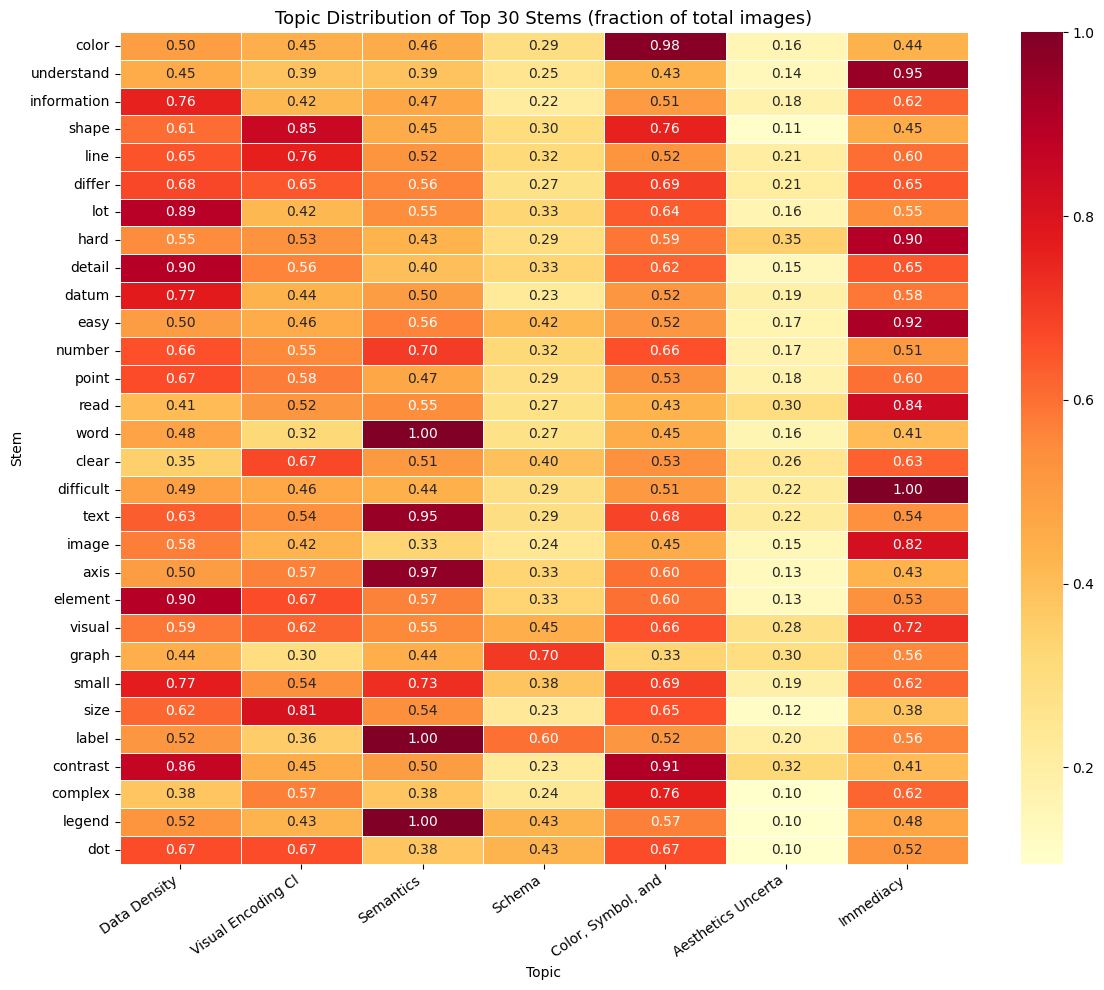

In [141]:
# ── Topic distribution heatmap (top 30 stems) ──────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

top30 = df_dict.head(30).copy()

# Normalize: fraction of each stem's total that comes from each topic
heat_data = top30[topic_names].div(top30['totalImages'], axis=0)
heat_data.index = top30['stem']

# Short topic labels for display
short_topics = [t.split('/')[0].split(' -')[0].strip()[:18] for t in topic_names]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    heat_data.values,
    xticklabels=short_topics,
    yticklabels=heat_data.index,
    cmap='YlOrRd',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    ax=ax,
)
ax.set_title('Topic Distribution of Top 30 Stems (fraction of total images)', fontsize=13)
ax.set_xlabel('Topic')
ax.set_ylabel('Stem')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

In [142]:
# ── VisType vocabulary profiles ──────────────────────────────────────────────────
CANONICAL_VISTYPES = ['Area', 'Bar', 'Cont.-ColorPatn', 'Glyph', 'Grid',
                      'Line', 'Node-link', 'Point', 'Text']

vistype_profiles = []
for vt in CANONICAL_VISTYPES:
    vt_imgs = df_out[df_out['VisType'] == vt]
    # Collect all stems for this VisType
    all_stems = []
    for s in vt_imgs['originalStems'].dropna():
        if s.strip():
            all_stems.extend([x.strip() for x in s.split(';') if x.strip()])
    stem_counts = Counter(all_stems)
    unique_count = len(stem_counts)
    top5 = stem_counts.most_common(5)

    vistype_profiles.append({
        'VisType': vt,
        'numImages': len(vt_imgs),
        'uniqueStems': unique_count,
        'stemsPerImage': round(unique_count / max(len(vt_imgs), 1), 1),
        'top5': ', '.join(f'{w} ({c})' for w, c in top5),
    })

df_vt_prof = pd.DataFrame(vistype_profiles)
print('VisType Vocabulary Profiles')
print('='*90)
for _, r in df_vt_prof.iterrows():
    print(f'\n■ {r["VisType"]:<18s}  {r["numImages"]:>3d} images | '
          f'{r["uniqueStems"]:>4d} unique stems | {r["stemsPerImage"]:>5.1f} stems/image')
    print(f'  Top 5: {r["top5"]}')

df_vt_prof

VisType Vocabulary Profiles

■ Area                 66 images |  235 unique stems |   3.6 stems/image
  Top 5: color (31), understand (15), easy (13), differ (11), read (10)

■ Bar                  52 images |  126 unique stems |   2.4 stems/image
  Top 5: color (18), understand (13), lot (7), bar (7), datum (6)

■ Cont.-ColorPatn      42 images |  166 unique stems |   4.0 stems/image
  Top 5: color (28), understand (7), hard (6), shape (6), information (6)

■ Glyph                64 images |  191 unique stems |   3.0 stems/image
  Top 5: color (19), shape (18), understand (15), differ (7), pattern (7)

■ Grid                 65 images |  187 unique stems |   2.9 stems/image
  Top 5: color (28), understand (14), information (13), lot (11), differ (9)

■ Line                 48 images |  154 unique stems |   3.2 stems/image
  Top 5: line (16), color (14), understand (11), number (10), hard (7)

■ Node-link            66 images |  225 unique stems |   3.4 stems/image
  Top 5: color (22),

,VisType,numImages,uniqueStems,stemsPerImage,top5
0,Area,66,235,3.6,"color (31), understand (15), easy (13), differ..."
1,Bar,52,126,2.4,"color (18), understand (13), lot (7), bar (7),..."
2,Cont.-ColorPatn,42,166,4.0,"color (28), understand (7), hard (6), shape (6..."
3,Glyph,64,191,3.0,"color (19), shape (18), understand (15), diffe..."
4,Grid,65,187,2.9,"color (28), understand (14), information (13),..."
5,Line,48,154,3.2,"line (16), color (14), understand (11), number..."
6,Node-link,66,225,3.4,"color (22), line (18), information (15), under..."
7,Point,58,189,3.3,"color (18), shape (14), information (13), poin..."
8,Text,51,131,2.6,"word (23), color (15), understand (10), size (..."


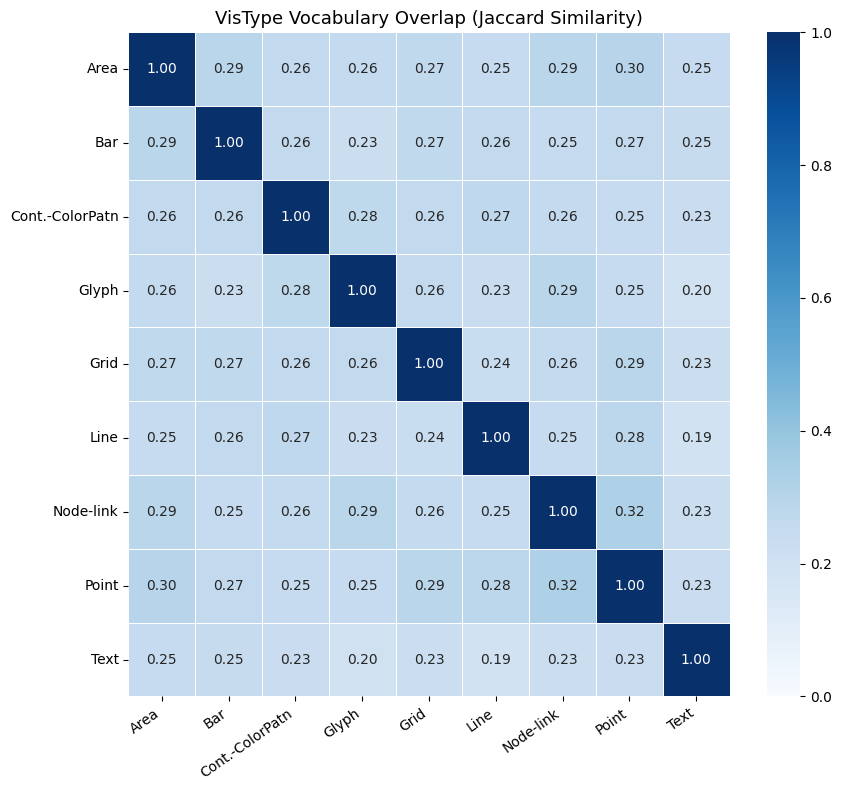


VisType-Exclusive Stems (not in any other VisType):

■ Area: 58 exclusive stems
  physical               2 images
  style                  2 images
  continent              2 images
  grow                   2 images
  geographic             2 images
  soft                   2 images
  pie                    2 images
  bright                 2 images
  varation               1 images
  knowledge              1 images

■ Bar: 20 exclusive stems
  horizontal             2 images
  crop                   1 images
  produce                1 images
  contain                1 images
  extend                 1 images
  gather                 1 images
  grasp                  1 images
  versus                 1 images
  orient                 1 images
  provoke                1 images

■ Cont.-ColorPatn: 35 exclusive stems
  blurry                 2 images
  suppose                2 images
  end                    1 images
  begin                  1 images
  single                 1 images
  e

In [143]:
# ── VisType Jaccard similarity + exclusive stems ────────────────────────────────
import numpy as np

# Build per-VisType stem sets
vt_stem_sets = {}
for vt in CANONICAL_VISTYPES:
    vt_imgs = df_out[df_out['VisType'] == vt]
    stems = set()
    for s in vt_imgs['originalStems'].dropna():
        if s.strip():
            stems.update(x.strip() for x in s.split(';') if x.strip())
    vt_stem_sets[vt] = stems

# Jaccard similarity matrix
n = len(CANONICAL_VISTYPES)
jaccard = np.zeros((n, n))
for i, vt1 in enumerate(CANONICAL_VISTYPES):
    for j, vt2 in enumerate(CANONICAL_VISTYPES):
        s1, s2 = vt_stem_sets[vt1], vt_stem_sets[vt2]
        if s1 or s2:
            jaccard[i, j] = len(s1 & s2) / len(s1 | s2)
        else:
            jaccard[i, j] = 0.0

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    jaccard,
    xticklabels=CANONICAL_VISTYPES,
    yticklabels=CANONICAL_VISTYPES,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0, vmax=1,
    linewidths=0.5,
    ax=ax,
)
ax.set_title('VisType Vocabulary Overlap (Jaccard Similarity)', fontsize=13)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

# Exclusive stems per VisType (not in any other VisType)
print('\nVisType-Exclusive Stems (not in any other VisType):')
all_vt_stems = set()
for s in vt_stem_sets.values():
    all_vt_stems.update(s)

for vt in CANONICAL_VISTYPES:
    others = set()
    for vt2 in CANONICAL_VISTYPES:
        if vt2 != vt:
            others.update(vt_stem_sets[vt2])
    exclusive = vt_stem_sets[vt] - others
    print(f'\n■ {vt}: {len(exclusive)} exclusive stems')
    if exclusive:
        # Show top by frequency
        vt_imgs = df_out[df_out['VisType'] == vt]
        exc_counts = Counter()
        for s in vt_imgs['originalStems'].dropna():
            if s.strip():
                for x in s.split(';'):
                    x = x.strip()
                    if x in exclusive:
                        exc_counts[x] += 1
        for w, c in exc_counts.most_common(10):
            print(f'  {w:<20s} {c:>3d} images')

## Dictionary vs. Visual Complexity

Analyze how stems relate to **NormalizedVC** (visual complexity):
1. Per-stem mean VC — which stems are associated with high/low complexity images?
2. VC-discriminating stems — stems that skew toward high or low VC
3. Stem frequency vs. VC correlation
4. High-VC vs. Low-VC vocabulary comparison

In [144]:
# ── Per-stem mean VC ────────────────────────────────────────────────────────────
# For each stem, compute mean NormalizedVC of images that contain it
overall_mean_vc = df_out['NormalizedVC'].mean()

stem_vc_stats = []
for _, drow in df_dict.iterrows():
    stem = drow['stem']
    # Find images containing this stem
    mask = df_out['originalStems'].fillna('').apply(
        lambda s: stem in [x.strip() for x in s.split(';')]
    )
    vc_vals = df_out.loc[mask, 'NormalizedVC'].dropna()
    if len(vc_vals) >= 2:
        stem_vc_stats.append({
            'stem': stem,
            'POS': drow['POS'],
            'totalImages': int(drow['totalImages']),
            'meanVC': vc_vals.mean(),
            'medianVC': vc_vals.median(),
            'stdVC': vc_vals.std(),
            'vcDelta': vc_vals.mean() - overall_mean_vc,  # deviation from global mean
        })

df_stem_vc = pd.DataFrame(stem_vc_stats).sort_values('vcDelta', ascending=False).reset_index(drop=True)

print(f'Overall mean NormalizedVC: {overall_mean_vc:.4f}')
print(f'Stems with ≥2 images: {len(df_stem_vc)}')
print(f'\n── Top 15 HIGH-VC stems (skew toward complex images) ──')
for _, r in df_stem_vc.head(15).iterrows():
    print(f'  {r["stem"]:<20s}  meanVC={r["meanVC"]:.3f}  Δ={r["vcDelta"]:+.3f}  ({r["totalImages"]} imgs)')

print(f'\n── Top 15 LOW-VC stems (skew toward simple images) ──')
for _, r in df_stem_vc.tail(15).iloc[::-1].iterrows():
    print(f'  {r["stem"]:<20s}  meanVC={r["meanVC"]:.3f}  Δ={r["vcDelta"]:+.3f}  ({r["totalImages"]} imgs)')


Overall mean NormalizedVC: 0.5954
Stems with ≥2 images: 344

── Top 15 HIGH-VC stems (skew toward complex images) ──
  grow                  meanVC=0.855  Δ=+0.260  (2 imgs)
  stuff                 meanVC=0.807  Δ=+0.211  (3 imgs)
  ascertain             meanVC=0.797  Δ=+0.201  (3 imgs)
  multitude             meanVC=0.790  Δ=+0.195  (3 imgs)
  vast                  meanVC=0.775  Δ=+0.180  (2 imgs)
  consider              meanVC=0.765  Δ=+0.170  (2 imgs)
  factor                meanVC=0.765  Δ=+0.170  (2 imgs)
  scatter               meanVC=0.762  Δ=+0.167  (4 imgs)
  define                meanVC=0.760  Δ=+0.165  (2 imgs)
  significant           meanVC=0.757  Δ=+0.161  (3 imgs)
  depth                 meanVC=0.755  Δ=+0.160  (2 imgs)
  vertical              meanVC=0.755  Δ=+0.160  (2 imgs)
  suppose               meanVC=0.755  Δ=+0.160  (2 imgs)
  able                  meanVC=0.747  Δ=+0.151  (3 imgs)
  variety               meanVC=0.743  Δ=+0.148  (9 imgs)

── Top 15 LOW-VC stems (ske

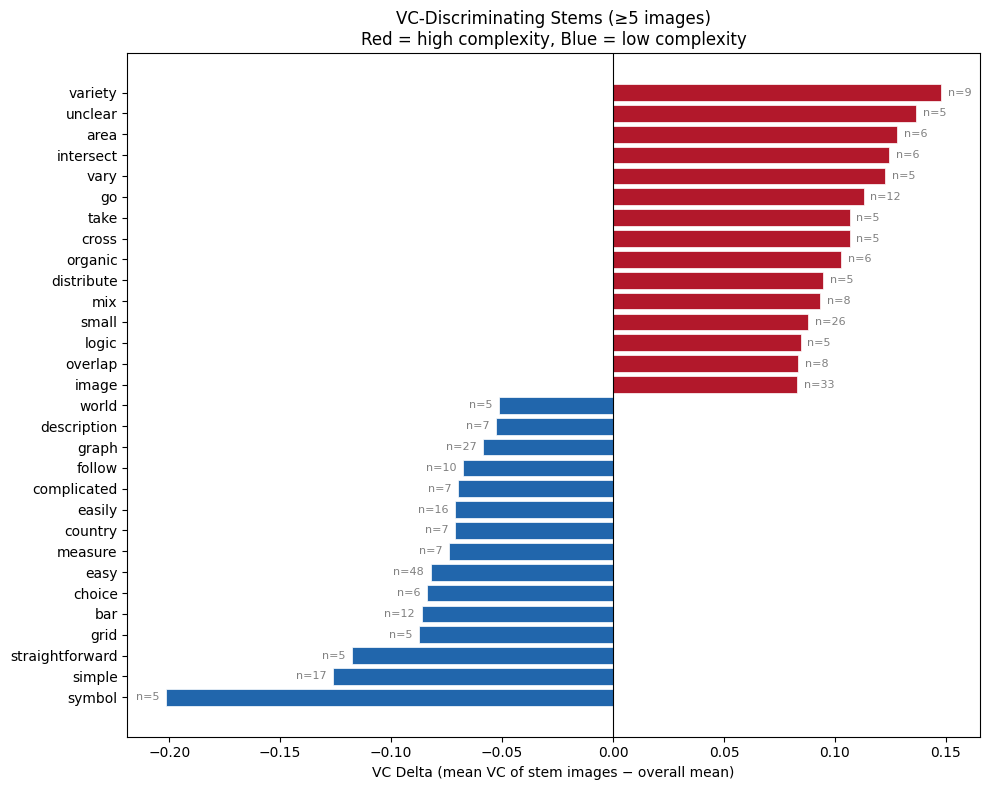

Stems shown: 30 (top/bottom 15 by VC delta, ≥5 images)


In [145]:
# ── VC-discriminating stems: diverging bar chart ────────────────────────────────
# Show stems with largest positive and negative VC delta (≥5 images for reliability)
reliable = df_stem_vc[df_stem_vc['totalImages'] >= 5].copy()

top_high = reliable.nlargest(15, 'vcDelta')
top_low = reliable.nsmallest(15, 'vcDelta')
plot_df = pd.concat([top_high, top_low]).drop_duplicates('stem').sort_values('vcDelta')

colors = ['#2166ac' if d < 0 else '#b2182b' for d in plot_df['vcDelta']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(plot_df['stem'], plot_df['vcDelta'], color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('VC Delta (mean VC of stem images − overall mean)')
ax.set_title('VC-Discriminating Stems (≥5 images)\nRed = high complexity, Blue = low complexity', fontsize=12)

# Annotate with image count
for bar, (_, r) in zip(bars, plot_df.iterrows()):
    x = bar.get_width()
    offset = 0.003 if x >= 0 else -0.003
    ha = 'left' if x >= 0 else 'right'
    ax.text(x + offset, bar.get_y() + bar.get_height()/2, f'n={r["totalImages"]}',
            va='center', ha=ha, fontsize=8, color='gray')

plt.tight_layout()
plt.show()

print(f'Stems shown: {len(plot_df)} (top/bottom 15 by VC delta, ≥5 images)')


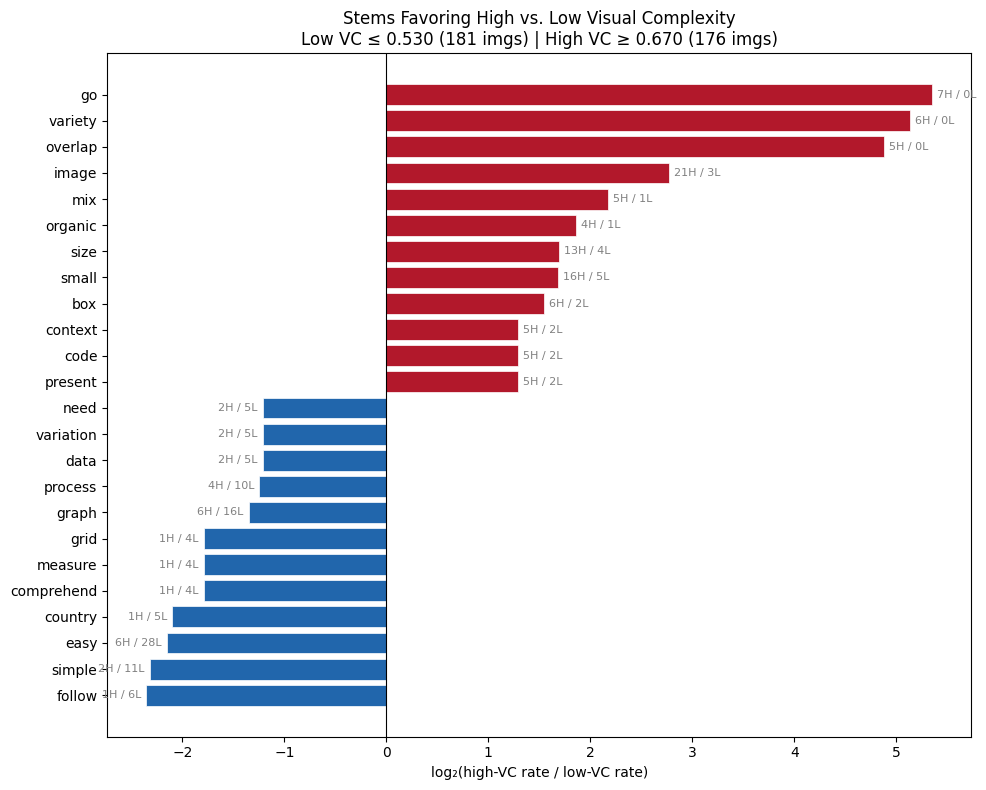


Vocabulary overlap:
  Shared stems: 189
  Only in low-VC images: 176
  Only in high-VC images: 200
  Jaccard similarity: 0.335


In [146]:
# ── High-VC vs. Low-VC vocabulary comparison ────────────────────────────────────
# Split images into terciles by NormalizedVC
vc_sorted = df_out['NormalizedVC'].dropna().sort_values()
low_thresh = vc_sorted.quantile(0.33)
high_thresh = vc_sorted.quantile(0.67)

df_low = df_out[df_out['NormalizedVC'] <= low_thresh]
df_high = df_out[df_out['NormalizedVC'] >= high_thresh]

def collect_stems(df_subset):
    counts = Counter()
    for s in df_subset['originalStems'].dropna():
        if s.strip():
            for x in s.split(';'):
                x = x.strip()
                if x:
                    counts[x] += 1
    return counts

low_counts = collect_stems(df_low)
high_counts = collect_stems(df_high)
all_vc_stems = set(low_counts.keys()) | set(high_counts.keys())

# Compute log-ratio: log2(high_freq / low_freq), with smoothing
vc_comparison = []
for stem in all_vc_stems:
    lc = low_counts.get(stem, 0)
    hc = high_counts.get(stem, 0)
    # Normalize by group size
    low_rate = lc / max(len(df_low), 1)
    high_rate = hc / max(len(df_high), 1)
    # Log ratio with smoothing
    log_ratio = np.log2((high_rate + 0.001) / (low_rate + 0.001))
    vc_comparison.append({
        'stem': stem,
        'lowVC_count': lc,
        'highVC_count': hc,
        'lowVC_rate': low_rate,
        'highVC_rate': high_rate,
        'logRatio': log_ratio,
        'total': lc + hc,
    })

df_vc_comp = pd.DataFrame(vc_comparison)
df_vc_comp = df_vc_comp[df_vc_comp['total'] >= 5]  # reliable only

# Plot top stems favoring high vs low VC
top_high_vc = df_vc_comp.nlargest(12, 'logRatio')
top_low_vc = df_vc_comp.nsmallest(12, 'logRatio')
plot_vc = pd.concat([top_high_vc, top_low_vc]).drop_duplicates('stem').sort_values('logRatio')

colors_vc = ['#2166ac' if lr < 0 else '#b2182b' for lr in plot_vc['logRatio']]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(plot_vc['stem'], plot_vc['logRatio'], color=colors_vc, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('log₂(high-VC rate / low-VC rate)')
ax.set_title(f'Stems Favoring High vs. Low Visual Complexity\n'
             f'Low VC ≤ {low_thresh:.3f} ({len(df_low)} imgs) | High VC ≥ {high_thresh:.3f} ({len(df_high)} imgs)',
             fontsize=12)

for bar, (_, r) in zip(bars, plot_vc.iterrows()):
    x = bar.get_width()
    offset = 0.05 if x >= 0 else -0.05
    ha = 'left' if x >= 0 else 'right'
    ax.text(x + offset, bar.get_y() + bar.get_height()/2,
            f'{int(r["highVC_count"])}H / {int(r["lowVC_count"])}L',
            va='center', ha=ha, fontsize=8, color='gray')

plt.tight_layout()
plt.show()

# Summary stats
shared = set(low_counts.keys()) & set(high_counts.keys())
only_low = set(low_counts.keys()) - set(high_counts.keys())
only_high = set(high_counts.keys()) - set(low_counts.keys())
print(f'\nVocabulary overlap:')
print(f'  Shared stems: {len(shared)}')
print(f'  Only in low-VC images: {len(only_low)}')
print(f'  Only in high-VC images: {len(only_high)}')
print(f'  Jaccard similarity: {len(shared)/len(shared | only_low | only_high):.3f}')


## Visual Complexity by Topic & VisType

How does **NormalizedVC** distribute across topics and VisTypes?
Which stems discriminate VC *within* each topic or VisType (not just globally)?

C:\Users\mling\AppData\Local\Temp\ipykernel_26860\2894436088.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_topic_vc, y='Topic', x='NormalizedVC', order=order_topic,
C:\Users\mling\AppData\Local\Temp\ipykernel_26860\2894436088.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_vt_vc, y='VisType', x='NormalizedVC', order=order_vt,


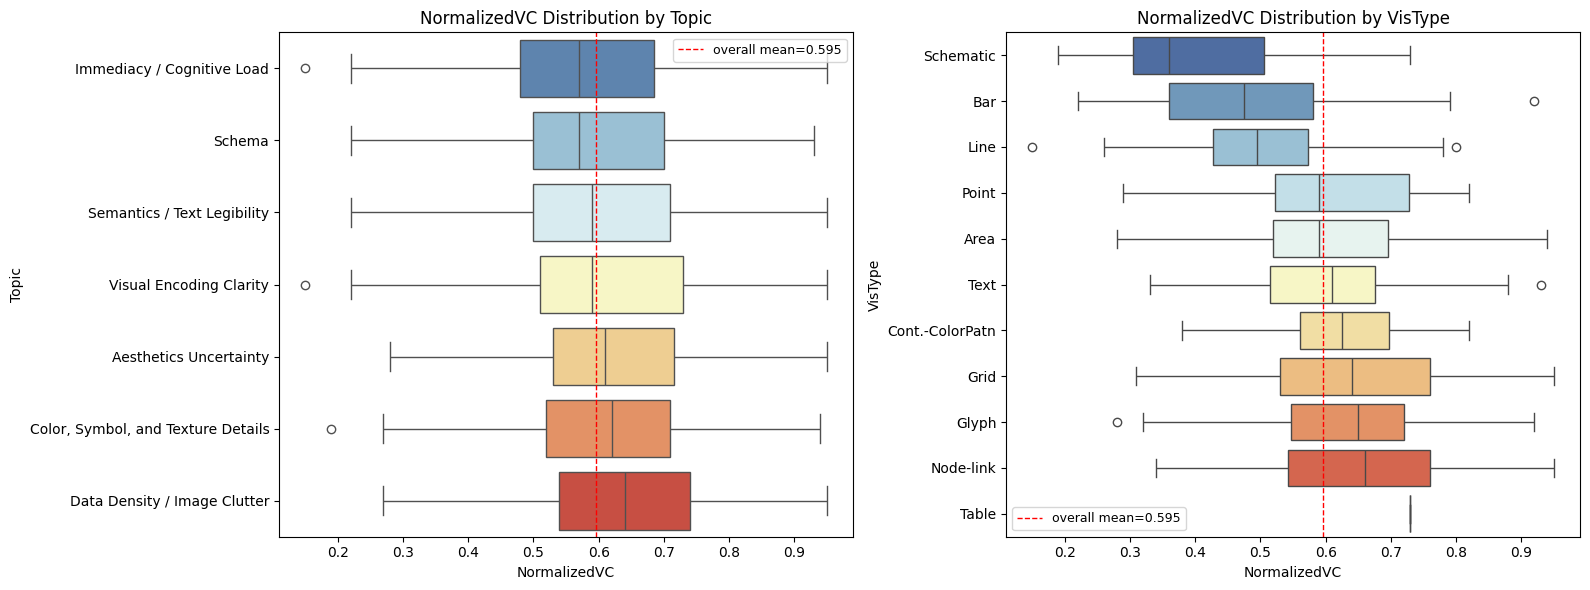

Topic VC Summary:
  Topic                                    mean median    std     n
  Immediacy / Cognitive Load              0.576  0.570  0.157   259
  Schema                                  0.591  0.570  0.150   125
  Semantics / Text Legibility             0.597  0.590  0.146   190
  Visual Encoding Clarity                 0.600  0.590  0.155   182
  Aesthetics Uncertainty                  0.622  0.610  0.137    55
  Color, Symbol, and Texture Details      0.611  0.620  0.145   230
  Data Density / Image Clutter            0.633  0.640  0.146   209

VisType VC Summary:
  VisType                mean median    std     n
  Schematic             0.414  0.360  0.180     7
  Bar                   0.491  0.475  0.159    52
  Line                  0.504  0.495  0.134    48
  Point                 0.602  0.590  0.131    58
  Area                  0.592  0.590  0.141    66
  Text                  0.605  0.610  0.130    51
  Cont.-ColorPatn       0.623  0.625  0.105    42
  Grid           

In [147]:
# ── VC distribution per Topic ────────────────────────────────────────────────────
# Each image can have multiple topics; explode to get per-topic VC stats
df_topic_vc = df_out[['NormalizedVC', 'Topics']].dropna().copy()
df_topic_vc['TopicList'] = df_topic_vc['Topics'].str.split(';')
df_topic_vc = df_topic_vc.explode('TopicList')
df_topic_vc['Topic'] = df_topic_vc['TopicList'].str.strip()
df_topic_vc = df_topic_vc[df_topic_vc['Topic'].isin(topic_names)]

# Box plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Topic boxplot
order_topic = df_topic_vc.groupby('Topic')['NormalizedVC'].median().sort_values().index.tolist()
sns.boxplot(data=df_topic_vc, y='Topic', x='NormalizedVC', order=order_topic,
            palette='RdYlBu_r', ax=axes[0])
axes[0].axvline(overall_mean_vc, color='red', ls='--', lw=1, label=f'overall mean={overall_mean_vc:.3f}')
axes[0].set_title('NormalizedVC Distribution by Topic', fontsize=12)
axes[0].legend(fontsize=9)

# VisType boxplot
df_vt_vc = df_out[['NormalizedVC', 'VisType']].dropna()
order_vt = df_vt_vc.groupby('VisType')['NormalizedVC'].median().sort_values().index.tolist()
sns.boxplot(data=df_vt_vc, y='VisType', x='NormalizedVC', order=order_vt,
            palette='RdYlBu_r', ax=axes[1])
axes[1].axvline(overall_mean_vc, color='red', ls='--', lw=1, label=f'overall mean={overall_mean_vc:.3f}')
axes[1].set_title('NormalizedVC Distribution by VisType', fontsize=12)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Stats table
print('Topic VC Summary:')
print(f'  {"Topic":<38s} {"mean":>6s} {"median":>6s} {"std":>6s} {"n":>5s}')
for topic in order_topic:
    sub = df_topic_vc[df_topic_vc['Topic'] == topic]['NormalizedVC']
    print(f'  {topic:<38s} {sub.mean():6.3f} {sub.median():6.3f} {sub.std():6.3f} {len(sub):5d}')

print(f'\nVisType VC Summary:')
print(f'  {"VisType":<20s} {"mean":>6s} {"median":>6s} {"std":>6s} {"n":>5s}')
for vt in order_vt:
    sub = df_vt_vc[df_vt_vc['VisType'] == vt]['NormalizedVC']
    print(f'  {vt:<20s} {sub.mean():6.3f} {sub.median():6.3f} {sub.std():6.3f} {len(sub):5d}')

In [148]:
# ── VC-discriminating stems WITHIN each topic ───────────────────────────────────
# For each topic, find stems whose images have significantly higher/lower VC
# compared to the topic's own mean VC

print('VC-DISCRIMINATING STEMS WITHIN EACH TOPIC')
print('(stems whose images deviate most from the topic mean VC, ≥3 images in topic)')
print('='*90)

topic_vc_stems = {}  # topic → DataFrame of stem VC stats
for topic in topic_names:
    # Get images in this topic
    topic_mask = df_out['Topics'].fillna('').str.contains(topic.replace('/', '\\/'), regex=False)
    topic_imgs = df_out[topic_mask]
    topic_mean = topic_imgs['NormalizedVC'].mean()

    rows = []
    for _, drow in df_dict[df_dict[topic] >= 3].iterrows():
        stem = drow['stem']
        # Find images in this topic that contain this stem
        stem_mask = topic_imgs['originalStems'].fillna('').apply(
            lambda s: stem in [x.strip() for x in s.split(';')]
        )
        vc_vals = topic_imgs.loc[stem_mask, 'NormalizedVC'].dropna()
        if len(vc_vals) >= 3:
            rows.append({
                'stem': stem,
                'nInTopic': len(vc_vals),
                'meanVC': vc_vals.mean(),
                'topicDelta': vc_vals.mean() - topic_mean,
            })

    if rows:
        df_t = pd.DataFrame(rows).sort_values('topicDelta', ascending=False)
        topic_vc_stems[topic] = df_t

        print(f'\n■ {topic}  (topic mean VC = {topic_mean:.3f}, {len(topic_imgs)} images)')
        print(f'  {"HIGH-VC stems":<35s}  {"LOW-VC stems"}')
        top_h = df_t.head(5)
        top_l = df_t.tail(5).iloc[::-1]
        for (_, h), (_, l) in zip(top_h.iterrows(), top_l.iterrows()):
            print(f'  {h["stem"]:<15s} Δ={h["topicDelta"]:+.3f} (n={h["nInTopic"]:>2d})  │  '
                  f'{l["stem"]:<15s} Δ={l["topicDelta"]:+.3f} (n={l["nInTopic"]:>2d})')

VC-DISCRIMINATING STEMS WITHIN EACH TOPIC
(stems whose images deviate most from the topic mean VC, ≥3 images in topic)

■ Visual Encoding Clarity  (topic mean VC = 0.600, 182 images)
  HIGH-VC stems                        LOW-VC stems
  cross           Δ=+0.160 (n= 4)  │  numerous        Δ=-0.173 (n= 3)
  distinguish     Δ=+0.147 (n= 3)  │  choice          Δ=-0.146 (n= 3)
  figure          Δ=+0.134 (n= 3)  │  straightforward Δ=-0.140 (n= 4)
  abstract        Δ=+0.134 (n= 3)  │  show            Δ=-0.135 (n= 6)
  area            Δ=+0.126 (n= 5)  │  way             Δ=-0.124 (n= 5)

■ Schema  (topic mean VC = 0.591, 125 images)
  HIGH-VC stems                        LOW-VC stems
  figure          Δ=+0.219 (n= 3)  │  bar             Δ=-0.205 (n= 5)
  go              Δ=+0.177 (n= 4)  │  straightforward Δ=-0.131 (n= 4)
  area            Δ=+0.164 (n= 4)  │  simple          Δ=-0.129 (n= 8)
  variety         Δ=+0.131 (n= 5)  │  follow          Δ=-0.109 (n= 5)
  fine            Δ=+0.126 (n= 3)  │

In [149]:
# ── VC-discriminating stems WITHIN each VisType ─────────────────────────────────
print('VC-DISCRIMINATING STEMS WITHIN EACH VISTYPE')
print('(stems whose images deviate most from the VisType mean VC, ≥3 images)')
print('='*90)

vistype_vc_stems = {}
for vt in CANONICAL_VISTYPES:
    vt_imgs = df_out[df_out['VisType'] == vt]
    vt_mean = vt_imgs['NormalizedVC'].mean()

    rows = []
    # Get stems present in this VisType
    vt_all_stems = Counter()
    for s in vt_imgs['originalStems'].dropna():
        if s.strip():
            for x in s.split(';'):
                x = x.strip()
                if x:
                    vt_all_stems[x] += 1

    for stem, cnt in vt_all_stems.items():
        if cnt < 3:
            continue
        stem_mask = vt_imgs['originalStems'].fillna('').apply(
            lambda s, st=stem: st in [x.strip() for x in s.split(';')]
        )
        vc_vals = vt_imgs.loc[stem_mask, 'NormalizedVC'].dropna()
        if len(vc_vals) >= 3:
            rows.append({
                'stem': stem,
                'nInVT': len(vc_vals),
                'meanVC': vc_vals.mean(),
                'vtDelta': vc_vals.mean() - vt_mean,
            })

    if rows:
        df_v = pd.DataFrame(rows).sort_values('vtDelta', ascending=False)
        vistype_vc_stems[vt] = df_v

        print(f'\n■ {vt:<18s}  (VisType mean VC = {vt_mean:.3f}, {len(vt_imgs)} images)')
        top_h = df_v.head(5)
        top_l = df_v.tail(5).iloc[::-1]
        print(f'  {"HIGH-VC stems":<35s}  {"LOW-VC stems"}')
        for (_, h), (_, l) in zip(top_h.iterrows(), top_l.iterrows()):
            print(f'  {h["stem"]:<15s} Δ={h["vtDelta"]:+.3f} (n={h["nInVT"]:>2d})  │  '
                  f'{l["stem"]:<15s} Δ={l["vtDelta"]:+.3f} (n={l["nInVT"]:>2d})')

VC-DISCRIMINATING STEMS WITHIN EACH VISTYPE
(stems whose images deviate most from the VisType mean VC, ≥3 images)

■ Area                (VisType mean VC = 0.592, 66 images)
  HIGH-VC stems                        LOW-VC stems
  size            Δ=+0.148 (n= 6)  │  easily          Δ=-0.132 (n= 3)
  value           Δ=+0.145 (n= 3)  │  chart           Δ=-0.122 (n= 4)
  multiple        Δ=+0.112 (n= 3)  │  world           Δ=-0.109 (n= 4)
  small           Δ=+0.110 (n= 7)  │  recognize       Δ=-0.102 (n= 3)
  image           Δ=+0.093 (n= 4)  │  country         Δ=-0.102 (n= 3)

■ Bar                 (VisType mean VC = 0.491, 52 images)
  HIGH-VC stems                        LOW-VC stems
  require         Δ=+0.149 (n= 3)  │  simple          Δ=-0.191 (n= 3)
  element         Δ=+0.129 (n= 4)  │  easy            Δ=-0.123 (n= 6)
  line            Δ=+0.116 (n= 4)  │  bar             Δ=-0.097 (n= 7)
  complex         Δ=+0.106 (n= 4)  │  graph           Δ=-0.095 (n= 5)
  lot             Δ=+0.099 (n= 7

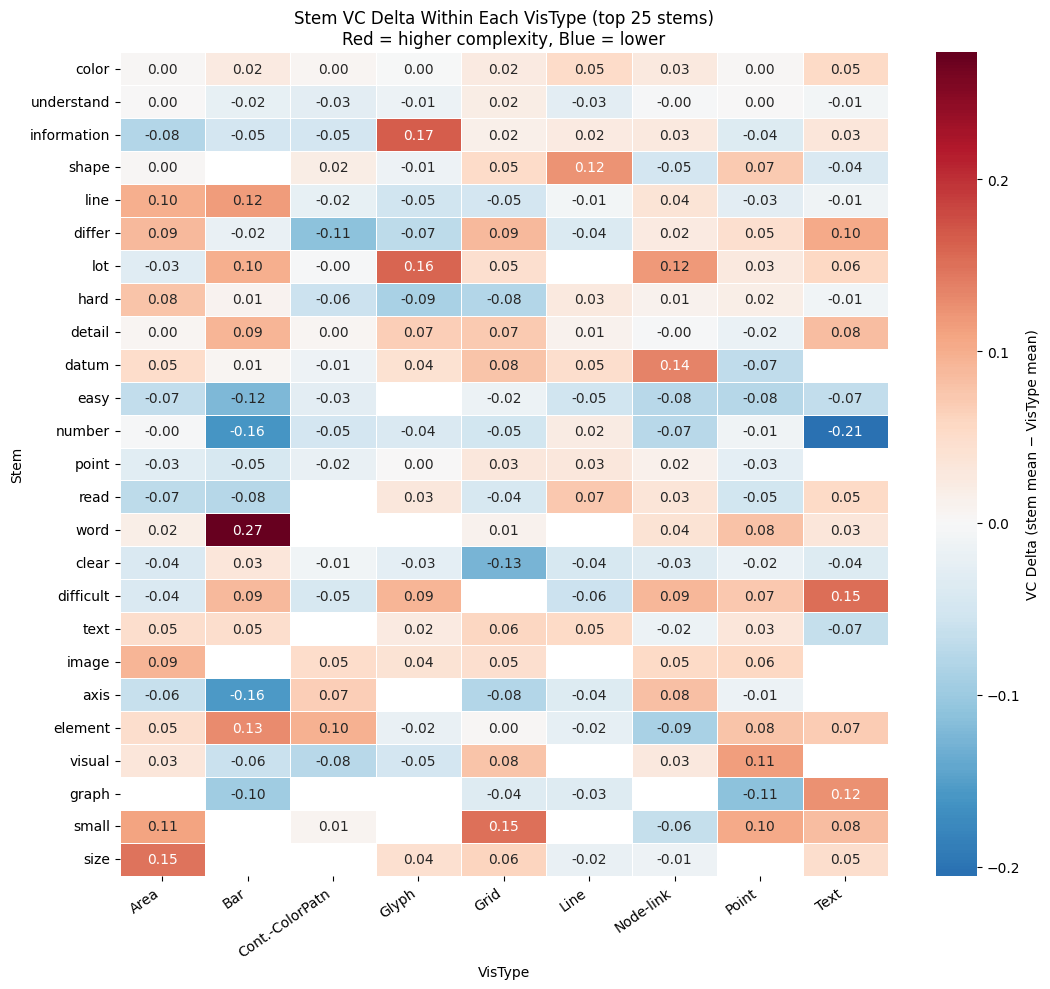

In [150]:
# ── Stem × VisType VC-delta heatmap ──────────────────────────────────────────────
# For top 25 most frequent stems, show their VC delta within each VisType
top_stems = df_dict.head(25)['stem'].tolist()

heat_rows = []
for stem in top_stems:
    row = {'stem': stem}
    for vt in CANONICAL_VISTYPES:
        vt_imgs = df_out[df_out['VisType'] == vt]
        vt_mean = vt_imgs['NormalizedVC'].mean()
        mask = vt_imgs['originalStems'].fillna('').apply(
            lambda s, st=stem: st in [x.strip() for x in s.split(';')]
        )
        vc_vals = vt_imgs.loc[mask, 'NormalizedVC'].dropna()
        row[vt] = (vc_vals.mean() - vt_mean) if len(vc_vals) >= 2 else np.nan
    heat_rows.append(row)

df_heat = pd.DataFrame(heat_rows).set_index('stem')

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(
    df_heat.values,
    xticklabels=CANONICAL_VISTYPES,
    yticklabels=df_heat.index,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    mask=np.isnan(df_heat.values),
    ax=ax,
    cbar_kws={'label': 'VC Delta (stem mean − VisType mean)'},
)
ax.set_title('Stem VC Delta Within Each VisType (top 25 stems)\nRed = higher complexity, Blue = lower', fontsize=12)
ax.set_xlabel('VisType')
ax.set_ylabel('Stem')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()